In [1]:
import random
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import numpy as np
import torch
from torch.autograd import Variable
import torch.nn.functional as F
import torch.utils.data as Data
import matplotlib.pyplot as plt
import math
import scienceplots
import matplotlib as mpl
from tqdm import tqdm

In [3]:
#1#: 第一步看sigmoid函数的过拟合情况
SEED = 1234#固定种子
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

x = torch.unsqueeze(torch.linspace(-2, 10, 19), dim=1)
y = np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2+1) + 0.12*torch.randn(x.size())  # 这里是污染数据固定不变当成训练数据



class custom(nn.Module):  # 激活函数含噪声参数
    def __init__(self,width):
        super().__init__()
        self.sigma = nn.Parameter(torch.randn(1))  # 1个可学习参数 sigma
        #self.theta = nn.Parameter(torch.randn(1, width))
    def forward(self, input):
        temp = 1/(1+torch.exp(-input/self.sigma)) # 前向传播
        return temp

class Net(torch.nn.Module):  # 定义网络
    def __init__(self, n_feature, n_hidden1, n_output):
        super(Net, self).__init__()
        self.hidden1 = torch.nn.Linear(n_feature, n_hidden1)  # 全连接层
        #self.custom1 = custom(n_hidden1)  # 自定义激活函数层
        self.predict = torch.nn.Linear(n_hidden1, n_output)   # 输出层

    def forward(self, x):

        x = self.hidden1(x)
        x = torch.sigmoid(x)
        x = self.predict(x)  # 前向传播过程
        return x

net = Net(n_feature=1, n_hidden1=14, n_output=1)
device = torch.device('cpu')#cpu计算就足够了，不是图像数据，所以不用GPU
optimizer = torch.optim.Adam(net.parameters(), lr=0.01, betas=(0.99,0.99))
#Adam算法，学习率是固定的0.01，矩参数是0.96

loss_func = torch.nn.MSELoss().to(device)  # loss函数是均方误差mse
x = x.to(device)
y = y.to(device)#把数据都载入到device上

In [4]:
# 假设 'net', 'x', 'y', 'loss_func', 和 'optimizer' 已经定义
epoch = 15000  # 训练次数
para0 = torch.zeros(epoch)  # 记录训练时每个epoch的loss函数值

# 固定随机种子
seeds = random.sample(range(1, 10000), 10)  # 生成10个随机种子
validation_epochs=[]
para1 = []
def test_with_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    xxx = torch.unsqueeze(torch.linspace(-2, 10, 30), dim=1)
    yyy = np.exp(-(xxx - 2)**2) + np.exp(-(xxx - 6)**2/10) + 1/ (xxx**2+1) + 0.12*torch.randn(xxx.size())
    predictiont = net(xxx)  # 前向过程
    losstest = loss_func(predictiont, yyy)  # 计算loss，通过prediction和y的差来计算mse
    return losstest.data.item()

# 开始训练和验证
for t in tqdm(range(epoch), desc="Training Progress"):
    prediction = net(x)  # 网络前向过程
    loss = loss_func(prediction, y)  # 计算loss，通过prediction和y的差来计算mse
    para0[t] = loss.data

    optimizer.zero_grad()  # 清除下一次训练的梯度
    loss.backward(retain_graph=True)  # 反向传播！
    optimizer.step()  # 更新参数
    
    # 验证并记录平均loss#每隔100次用10组数据进行了验证
    if t == 0 or (t + 1) % 100 == 0:
        validation_epochs.append(t + 1)
        losses = [test_with_seed(seed) for seed in seeds]
        average_loss = sum(losses) / len(losses)
        para1.append(average_loss)
        print(f'Epoch {t + 1}: Validation Average Loss = {average_loss}')

Training Progress:   2%|█                                                         | 275/15000 [00:01<00:37, 395.58it/s]

Epoch 1: Validation Average Loss = 1.0526690781116486
Epoch 100: Validation Average Loss = 0.10183337032794952
Epoch 200: Validation Average Loss = 0.10111086294054986


Training Progress:   4%|██                                                        | 532/15000 [00:01<00:20, 714.17it/s]

Epoch 300: Validation Average Loss = 0.054474498331546786
Epoch 400: Validation Average Loss = 0.048543012142181395
Epoch 500: Validation Average Loss = 0.043998900428414346


Training Progress:   5%|███                                                       | 800/15000 [00:01<00:14, 953.17it/s]

...

Epoch 14400: Validation Average Loss = 0.04028057046234608
Epoch 14500: Validation Average Loss = 0.04076761156320572
Epoch 14600: Validation Average Loss = 0.041282637789845464


Training Progress:  99%|██████████████████████████████████████████████████████▍| 14834/15000 [00:12<00:00, 1305.85it/s]

Epoch 14700: Validation Average Loss = 0.04171837642788887
Epoch 14800: Validation Average Loss = 0.04214316643774509
Epoch 14900: Validation Average Loss = 0.04249707274138927


Training Progress: 100%|███████████████████████████████████████████████████████| 15000/15000 [00:12<00:00, 1176.41it/s]

Epoch 15000: Validation Average Loss = 0.042832794785499576


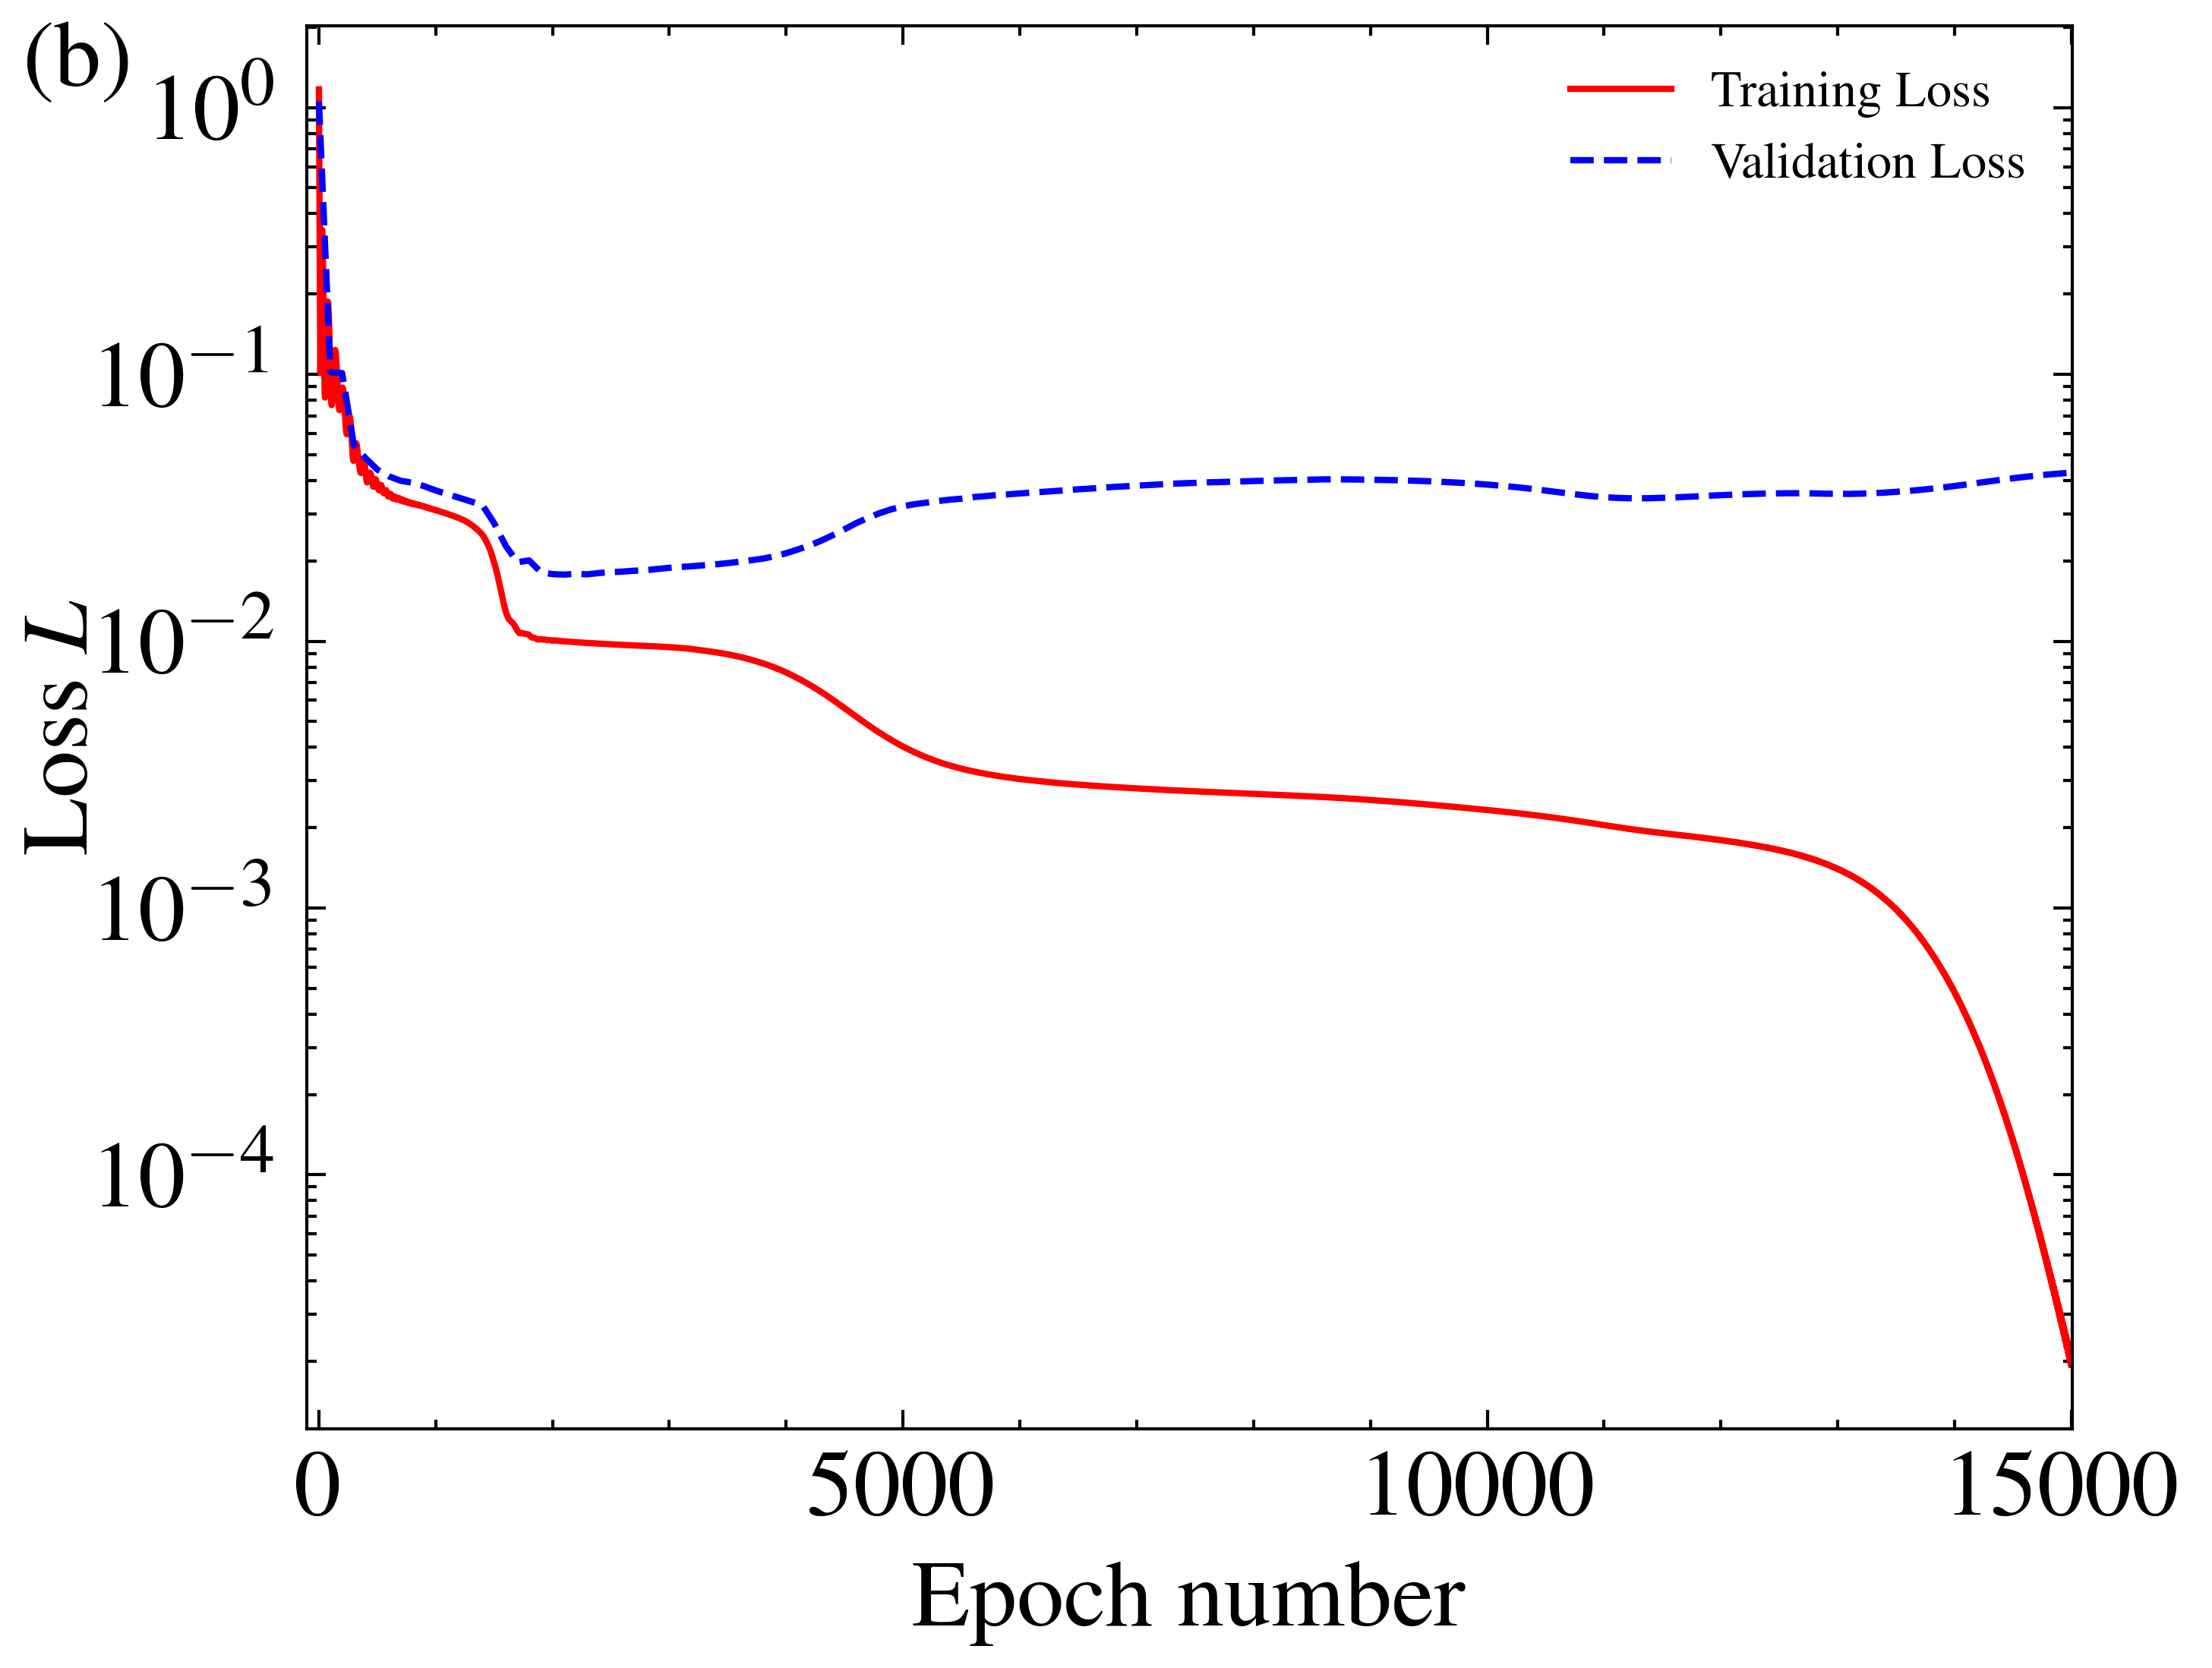

In [5]:
# 绘制训练和验证的loss曲线
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = True
plt.style.use(['science', 'ieee'])

fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('Epoch number', fontsize=15)
ax.set_ylabel('Loss $L$', fontsize=15, labelpad=-1)
ax.set_xlim(-100, 15010)
ax.set_yscale('log')  # 设置y轴为对数坐标
ax.text(-2500, 1.2, '(b)', fontdict={'size': 15, 'color': 'black'})

ax.plot(range(1, epoch + 1), para0.numpy(), 'r-', lw=1, label='Training Loss')
ax.plot(validation_epochs, para1, 'b--', lw=1, label='Validation Loss')
plt.legend()
#plt.savefig('D:/PLA2024/Fig2b.eps', format='eps')
plt.show()

#np.savetxt('D:/MST2024/para0.csv', para0.numpy(), delimiter=',', header='para0', comments='')
#np.savetxt('D:/MST2024/para1.csv', para1, delimiter=',', header='para1', comments='')

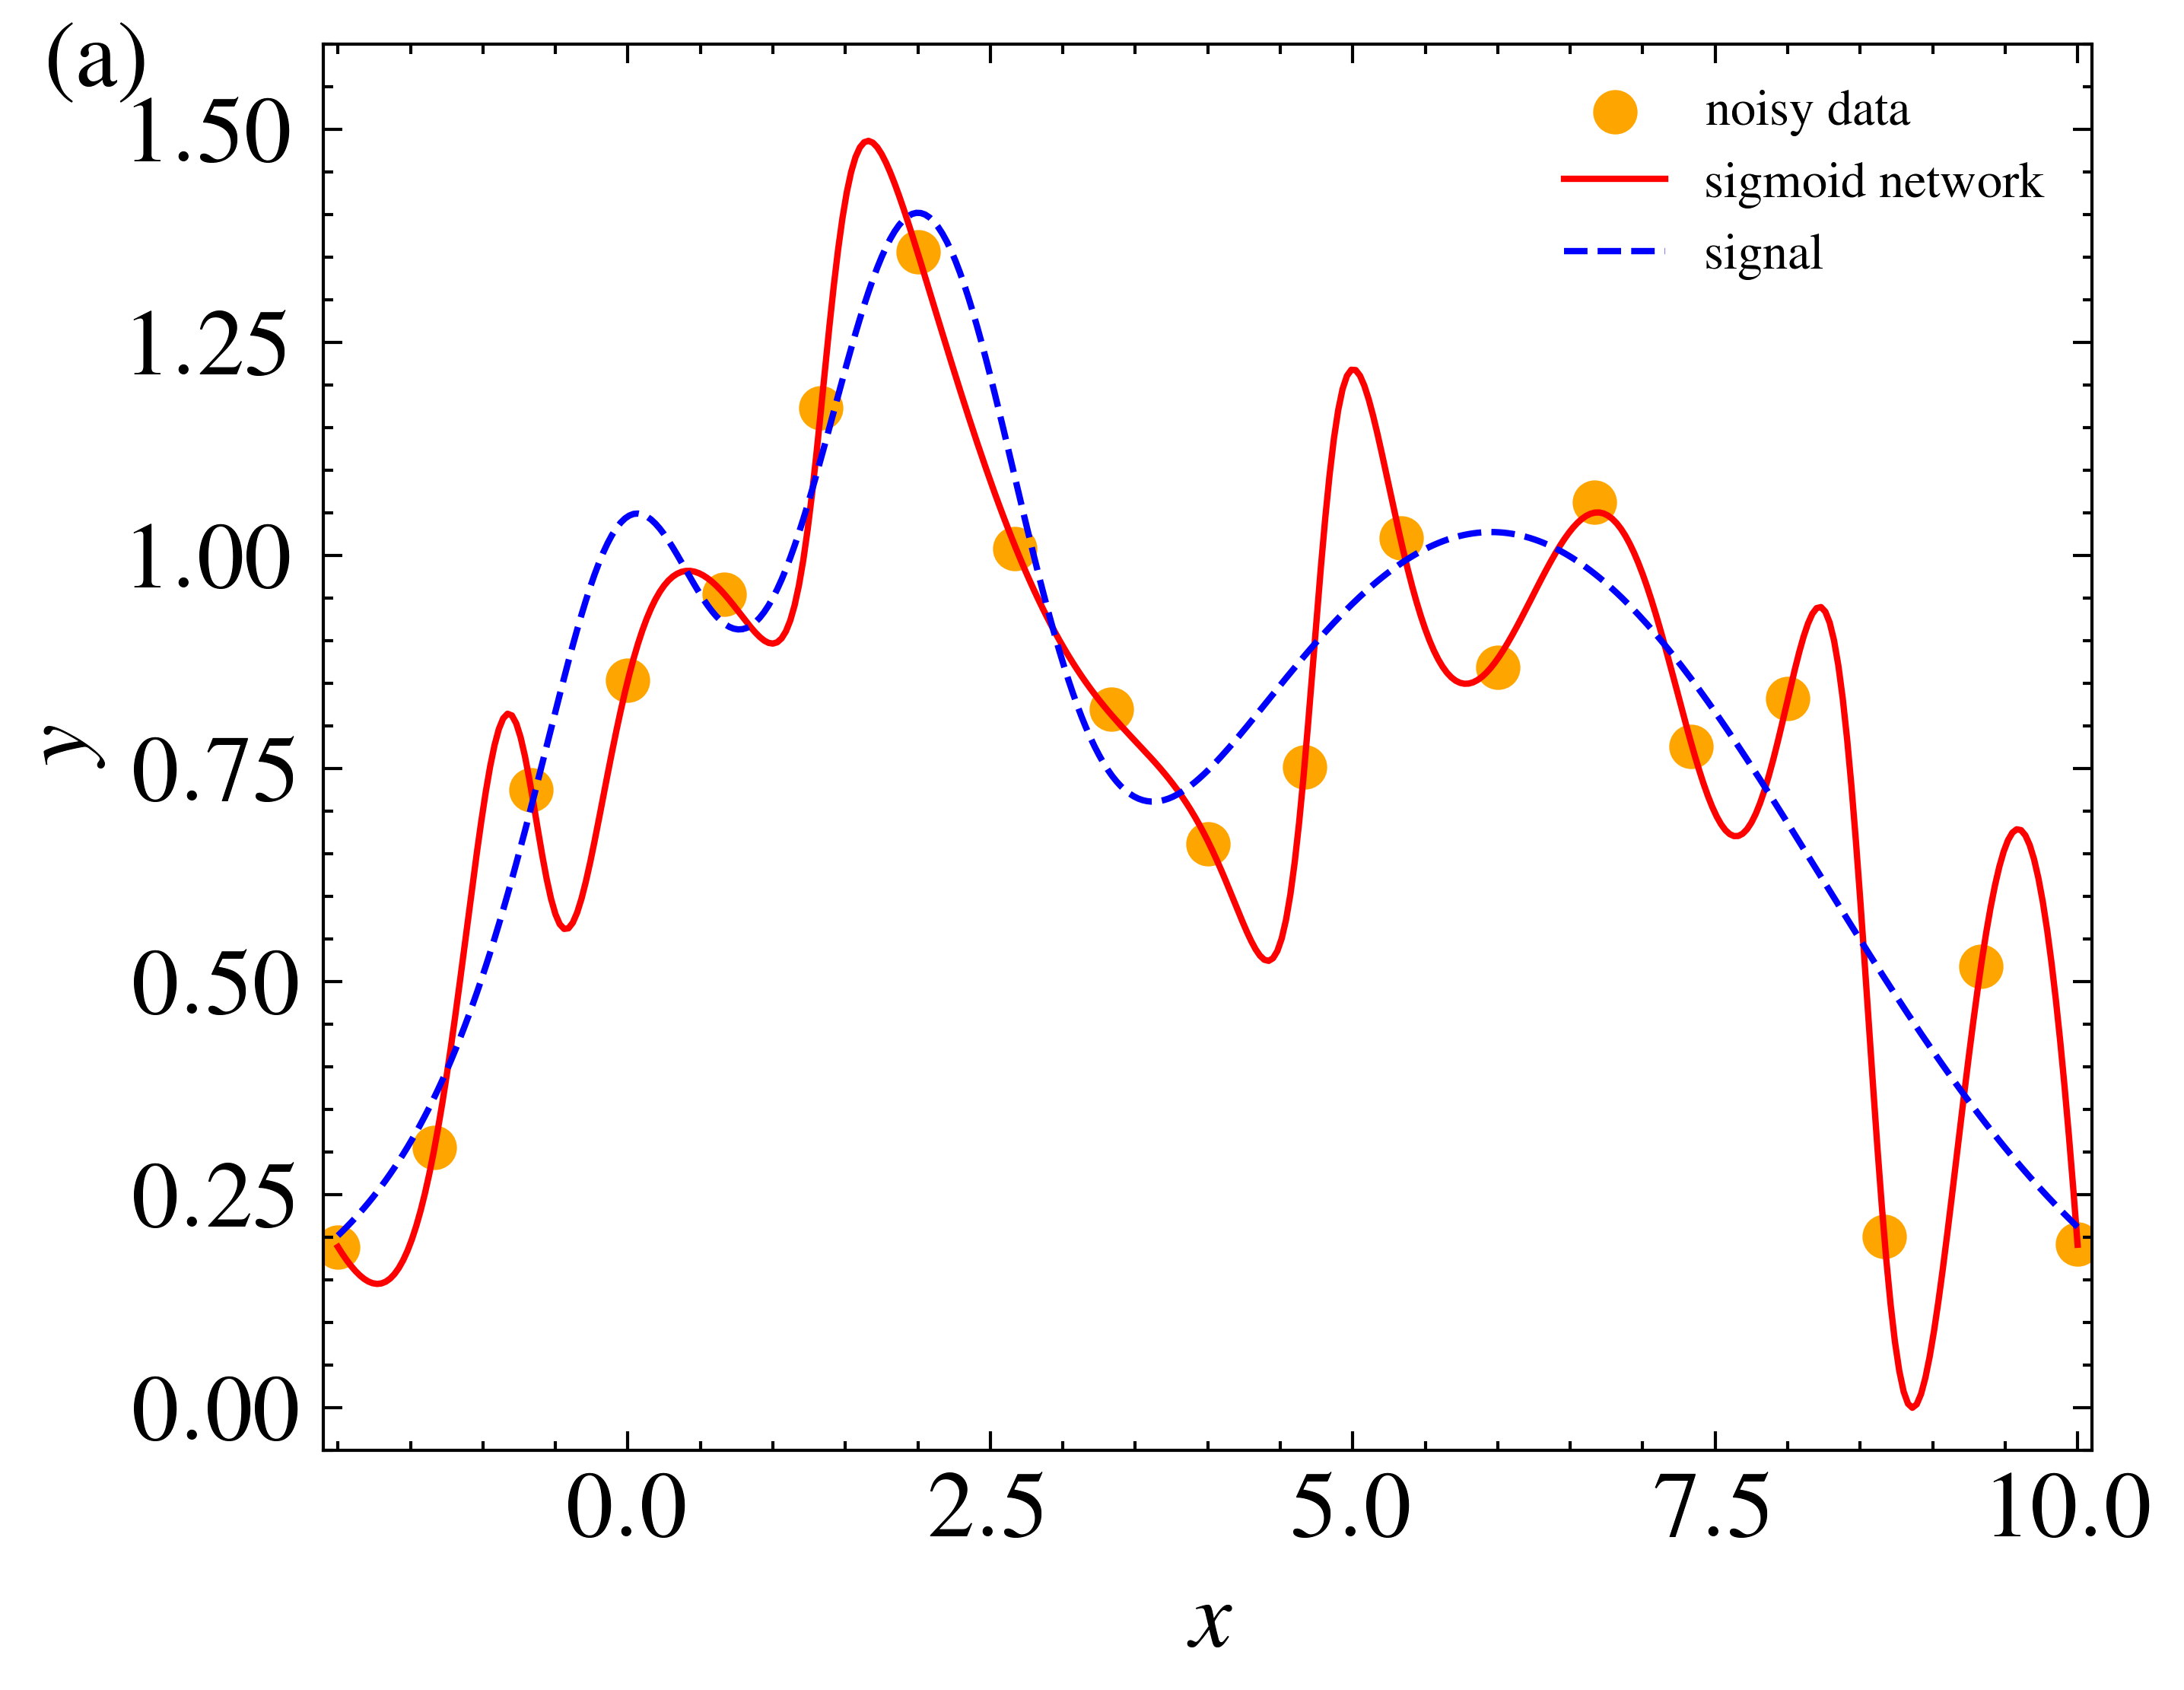

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

# Configure plot settings
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = True
plt.style.use(['science', 'ieee'])

# Generate figure and axis
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('$x$', fontsize=15)
ax.set_ylabel('$y$', fontsize=15)
ax.set_xlim(-2.1, 10.1)
ax.set_ylim(-0.05, 1.6)

# Scatter plot for training set
ax.scatter(x.data.numpy(), y.data.numpy(), color="orange", label='noisy data')

# Generate input and output for the plot
input = torch.unsqueeze(torch.linspace(-2, 10, 401), dim=1)
output = net(input)

# Plot network fitting output
ax.plot(input.data.numpy(), output.data.numpy(), 'r-', lw=1, label='sigmoid network')

# True signal
signal = np.exp(-(input - 2)**2) + np.exp(-(input - 6)**2 / 10) + 1 / (input**2 + 1)
ax.plot(input.data.numpy(), signal.data.numpy(), 'b--', lw=1, label='signal')

# Save output to CSV file
output_data = np.hstack((input.data.numpy(), output.data.numpy()))
#np.savetxt('D:/MST2024/outputsigmoid.csv', output_data, delimiter=',', header='x,output', comments='')
ax.text(-4, 1.55, '(a)',fontdict={'size': 15, 'color':  'black'})
# Save figure as EPS file
plt.legend()
#plt.savefig('D:/PLA2024/Fig2a.eps', format='eps')
plt.show()

#如果修改的话，重新读取数据
# data = np.loadtxt('D:/PLA2024/outputsigmoid.csv', delimiter=',', skiprows=1)

# # 分割读取的数据
# input_data = data[:, 0]
# output_values = data[:, 1]

In [7]:
class custom(nn.Module):  # 激活函数含噪声参数
    def __init__(self,width):
        super().__init__()
    def forward(self, input):
        #temp = 1/(1+torch.exp(-input/self.sigma)) # 前向传播
        temp = (1+torch.erf(input/math.sqrt(2)/5.0))/2
        return temp

class Net(torch.nn.Module):  # 定义网络
    def __init__(self, n_feature, n_hidden1, n_output):
        super(Net, self).__init__()
        self.hidden1 = torch.nn.Linear(n_feature, n_hidden1)  # 全连接层
        self.custom1 = custom(n_hidden1)  # 自定义激活函数层
        self.predict = torch.nn.Linear(n_hidden1, n_output)   # 输出层

    def forward(self, x):

        x = self.hidden1(x)
        x = self.custom1(x)
        x = self.predict(x)  # 前向传播过程
        return x

net = Net(n_feature=1, n_hidden1=14, n_output=1)
device = torch.device('cpu')#cpu计算就足够了，不是图像数据，所以不用GPU
optimizer = torch.optim.Adam(net.parameters(), lr=0.01, betas=(0.99,0.99))
#Adam算法，学习率是固定的0.01，矩参数是0.96

loss_func = torch.nn.MSELoss().to(device)  # loss函数是均方误差mse
# 假设 'net', 'x', 'y', 'loss_func', 和 'optimizer' 已经定义
epoch = 15000  # 训练次数
para0g = torch.zeros(epoch)  # 记录训练时每个epoch的loss函数值

# 固定随机种子
seeds = random.sample(range(1, 10000), 10)  # 生成10个随机种子
validation_epochs=[]
para1g = []
def test_with_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    xxx = torch.unsqueeze(torch.linspace(-2, 10, 30), dim=1)
    yyy = np.exp(-(xxx - 2)**2) + np.exp(-(xxx - 6)**2/10) + 1/ (xxx**2+1) + 0.12*torch.randn(xxx.size())
    predictiont = net(xxx)  # 前向过程
    losstest = loss_func(predictiont, yyy)  # 计算loss，通过prediction和y的差来计算mse
    return losstest.data.item()

# 开始训练和验证
for t in tqdm(range(epoch), desc="Training Progress"):
    prediction = net(x)  # 网络前向过程
    loss = loss_func(prediction, y)  # 计算loss，通过prediction和y的差来计算mse
    para0g[t] = loss.data

    optimizer.zero_grad()  # 清除下一次训练的梯度
    loss.backward(retain_graph=True)  # 反向传播！
    optimizer.step()  # 更新参数
    
    # 验证并记录平均loss#每隔100次用10组数据进行了验证
    if t == 0 or (t + 1) % 100 == 0:
        validation_epochs.append(t + 1)
        losses = [test_with_seed(seed) for seed in seeds]
        average_loss = sum(losses) / len(losses)
        para1g.append(average_loss)
        print(f'Epoch {t + 1}: Validation Average Loss = {average_loss}')

Training Progress:   2%|▉                                                         | 231/15000 [00:00<00:27, 546.22it/s]

Epoch 1: Validation Average Loss = 1.1767929911613464
Epoch 100: Validation Average Loss = 0.10896996930241584
Epoch 200: Validation Average Loss = 0.13485347852110863


Training Progress:   3%|█▊                                                        | 463/15000 [00:00<00:17, 843.22it/s]

Epoch 300: Validation Average Loss = 0.0943322665989399
Epoch 400: Validation Average Loss = 0.06371105499565602
Epoch 500: Validation Average Loss = 0.05943980328738689


Training Progress:   5%|██▋                                                       | 700/15000 [00:01<00:14, 974.59it/s]

...

Epoch 14500: Validation Average Loss = 0.022344800271093847
Epoch 14600: Validation Average Loss = 0.022390847187489273


Training Progress:  99%|███████████████████████████████████████████████████████▋| 14908/15000 [00:14<00:00, 953.44it/s]

Epoch 14700: Validation Average Loss = 0.022493541799485685
Epoch 14800: Validation Average Loss = 0.022585918474942446
Epoch 14900: Validation Average Loss = 0.022612606827169656


Training Progress: 100%|███████████████████████████████████████████████████████| 15000/15000 [00:14<00:00, 1042.12it/s]

Epoch 15000: Validation Average Loss = 0.022723368462175132


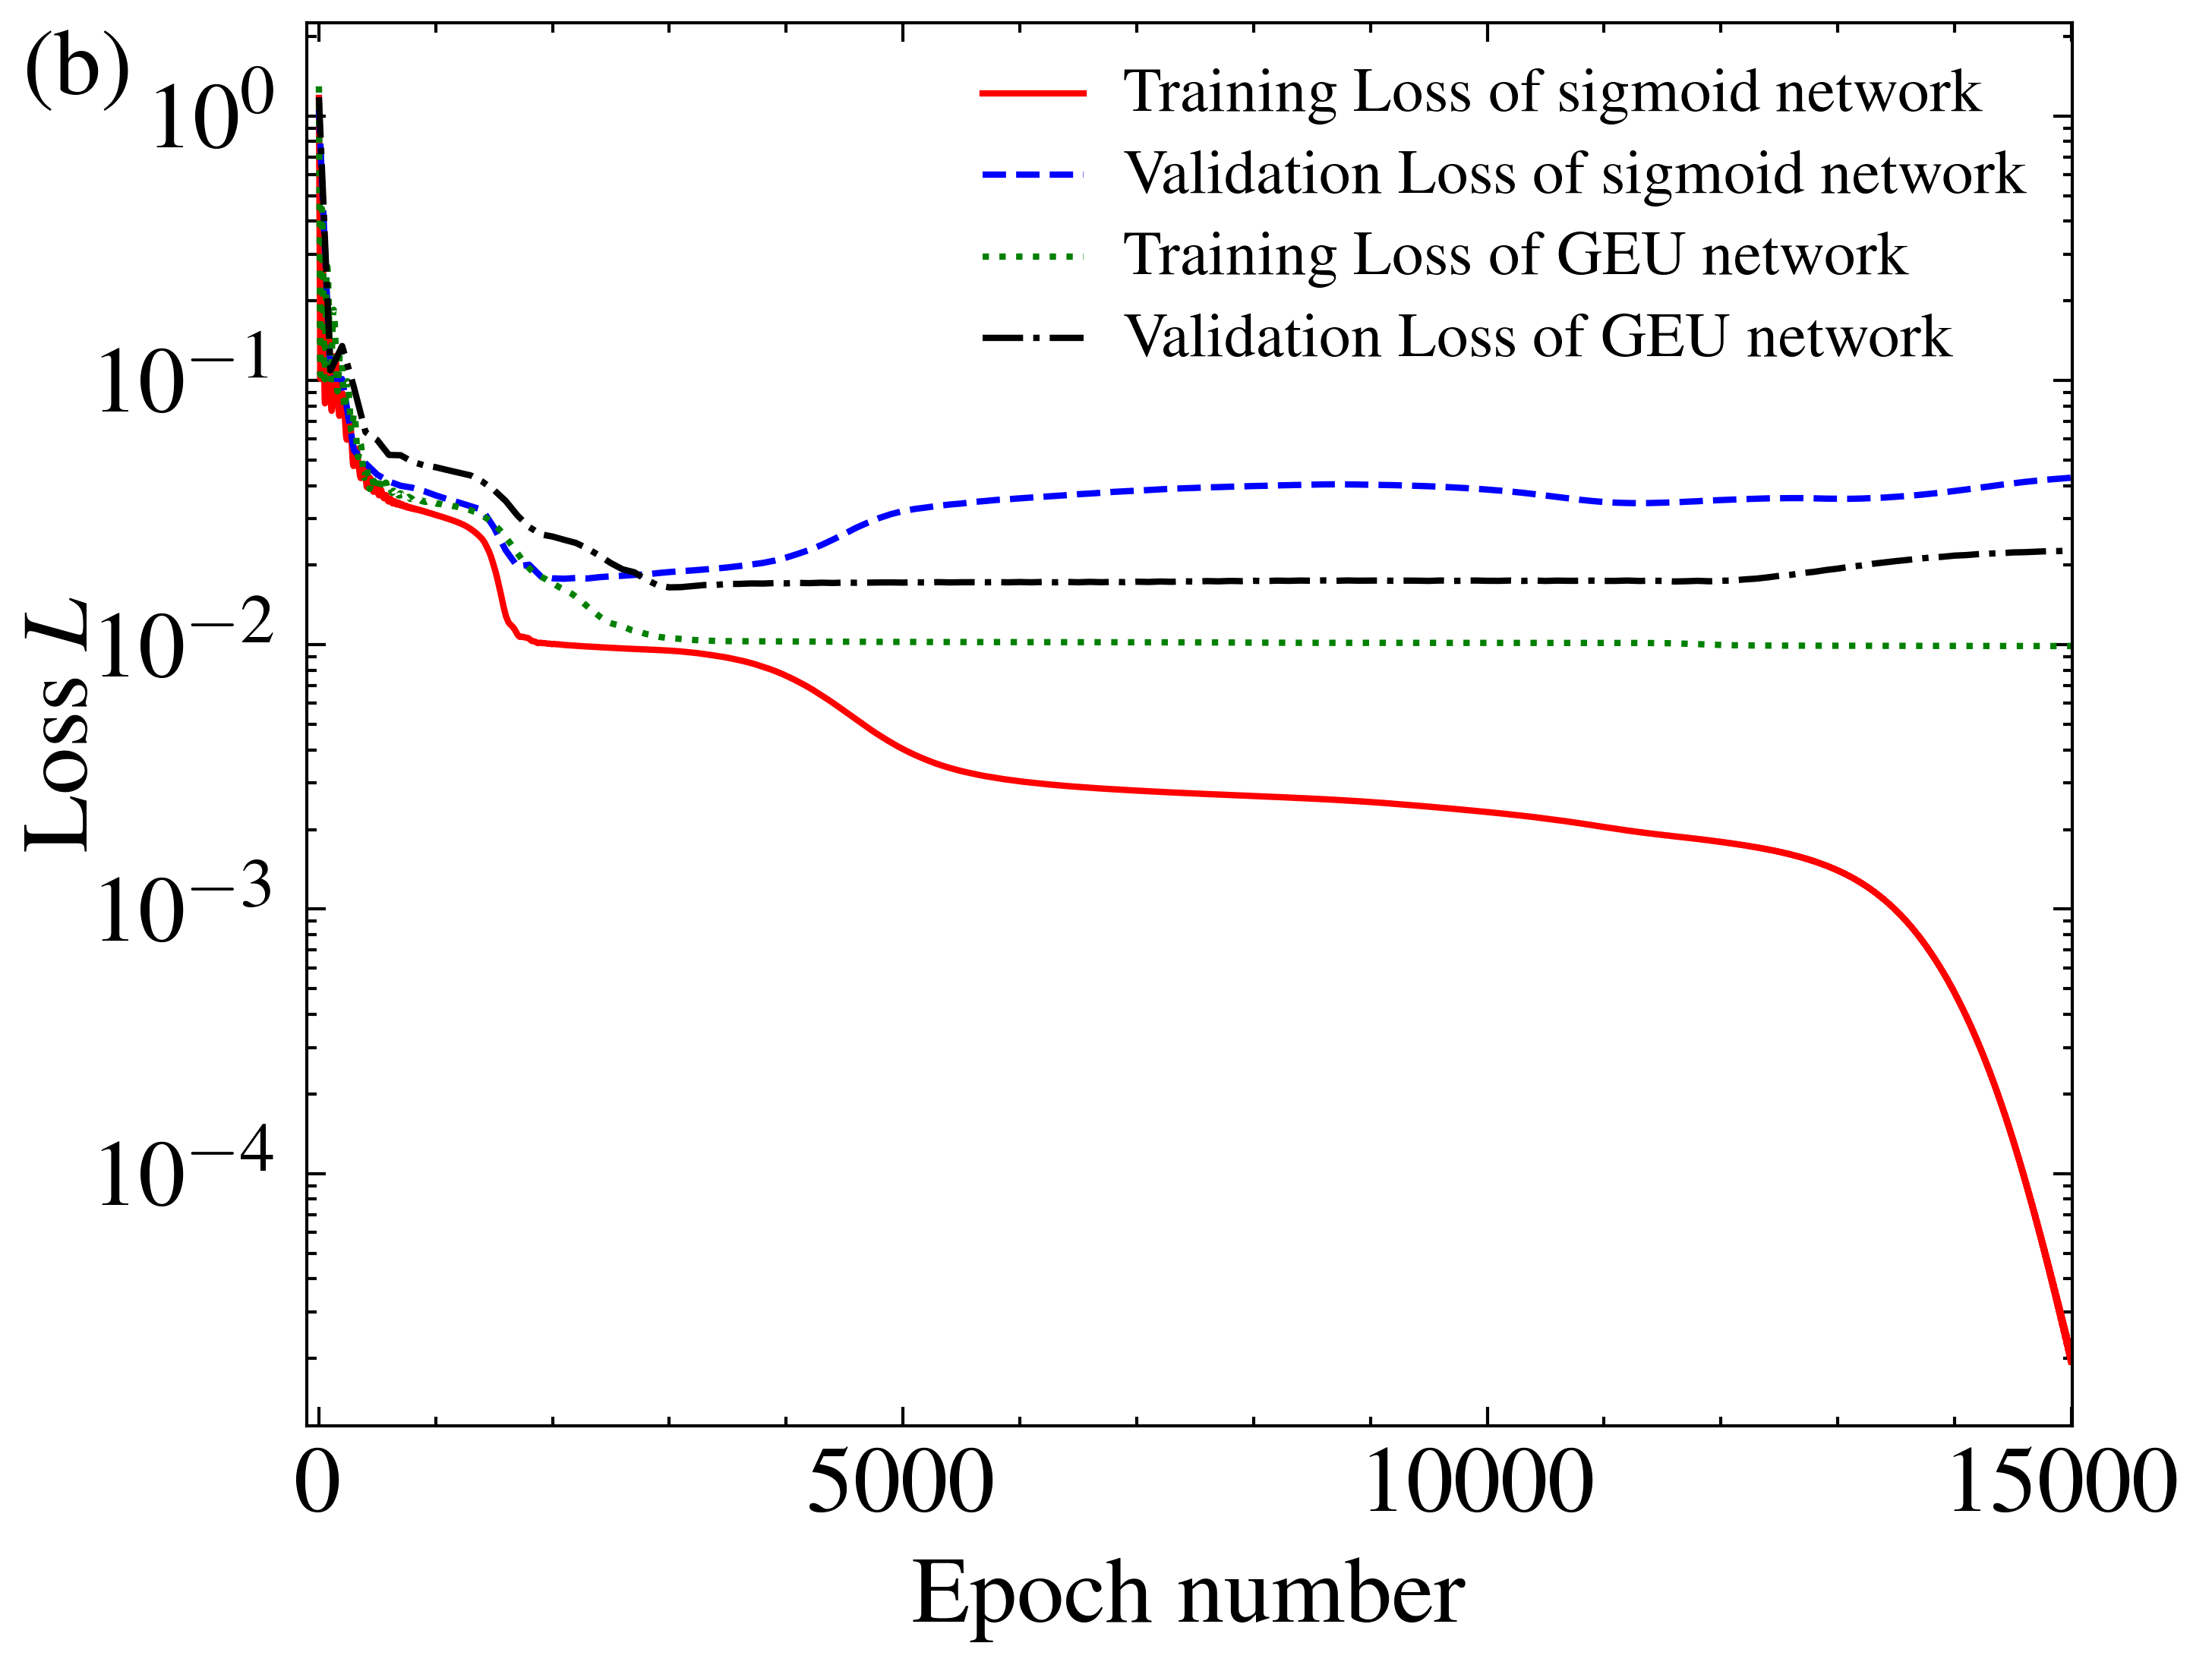

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = True
plt.style.use(['science', 'ieee'])

fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('Epoch number', fontsize=15)
ax.set_ylabel('Loss $L$', fontsize=15, labelpad=-1)
ax.set_xlim(-100, 15010)
ax.set_yscale('log')  # 设置y轴为对数坐标
ax.text(-2500, 1.2, '(b)', fontdict={'size': 15, 'color': 'black'})
ax.plot(range(1, epoch + 1), para0.numpy(), 'r-', lw=1, label='Training Loss of sigmoid network')  # Red solid line
ax.plot(validation_epochs, para1, 'b--', lw=1, label='Validation Loss of sigmoid network')  # Blue dashed line
ax.plot(range(1, epoch + 1), para0g.numpy(), 'g:', lw=1, label='Training Loss of GEU network')  # Green dotted line
ax.plot(validation_epochs, para1g, 'k-.', lw=1, label='Validation Loss of GEU network')  # Purple dash-dot line

# 修改legend字体大小
legend = ax.legend()  # 获取legend对象
for text in legend.get_texts():  # 遍历legend中的文本
    plt.setp(text, fontsize=10)  # 设置字体大小为12

# 或者更简洁的方式
# plt.legend(fontsize=12)

plt.savefig('D:/MST2024/Fig2b.eps', format='eps')
plt.show()

#np.savetxt('D:/MST2024/para0g.csv', para0g.numpy(), delimiter=',', header='para0', comments='')
#np.savetxt('D:/MST2024/para1g.csv', para1g, delimiter=',', header='para1', comments='')

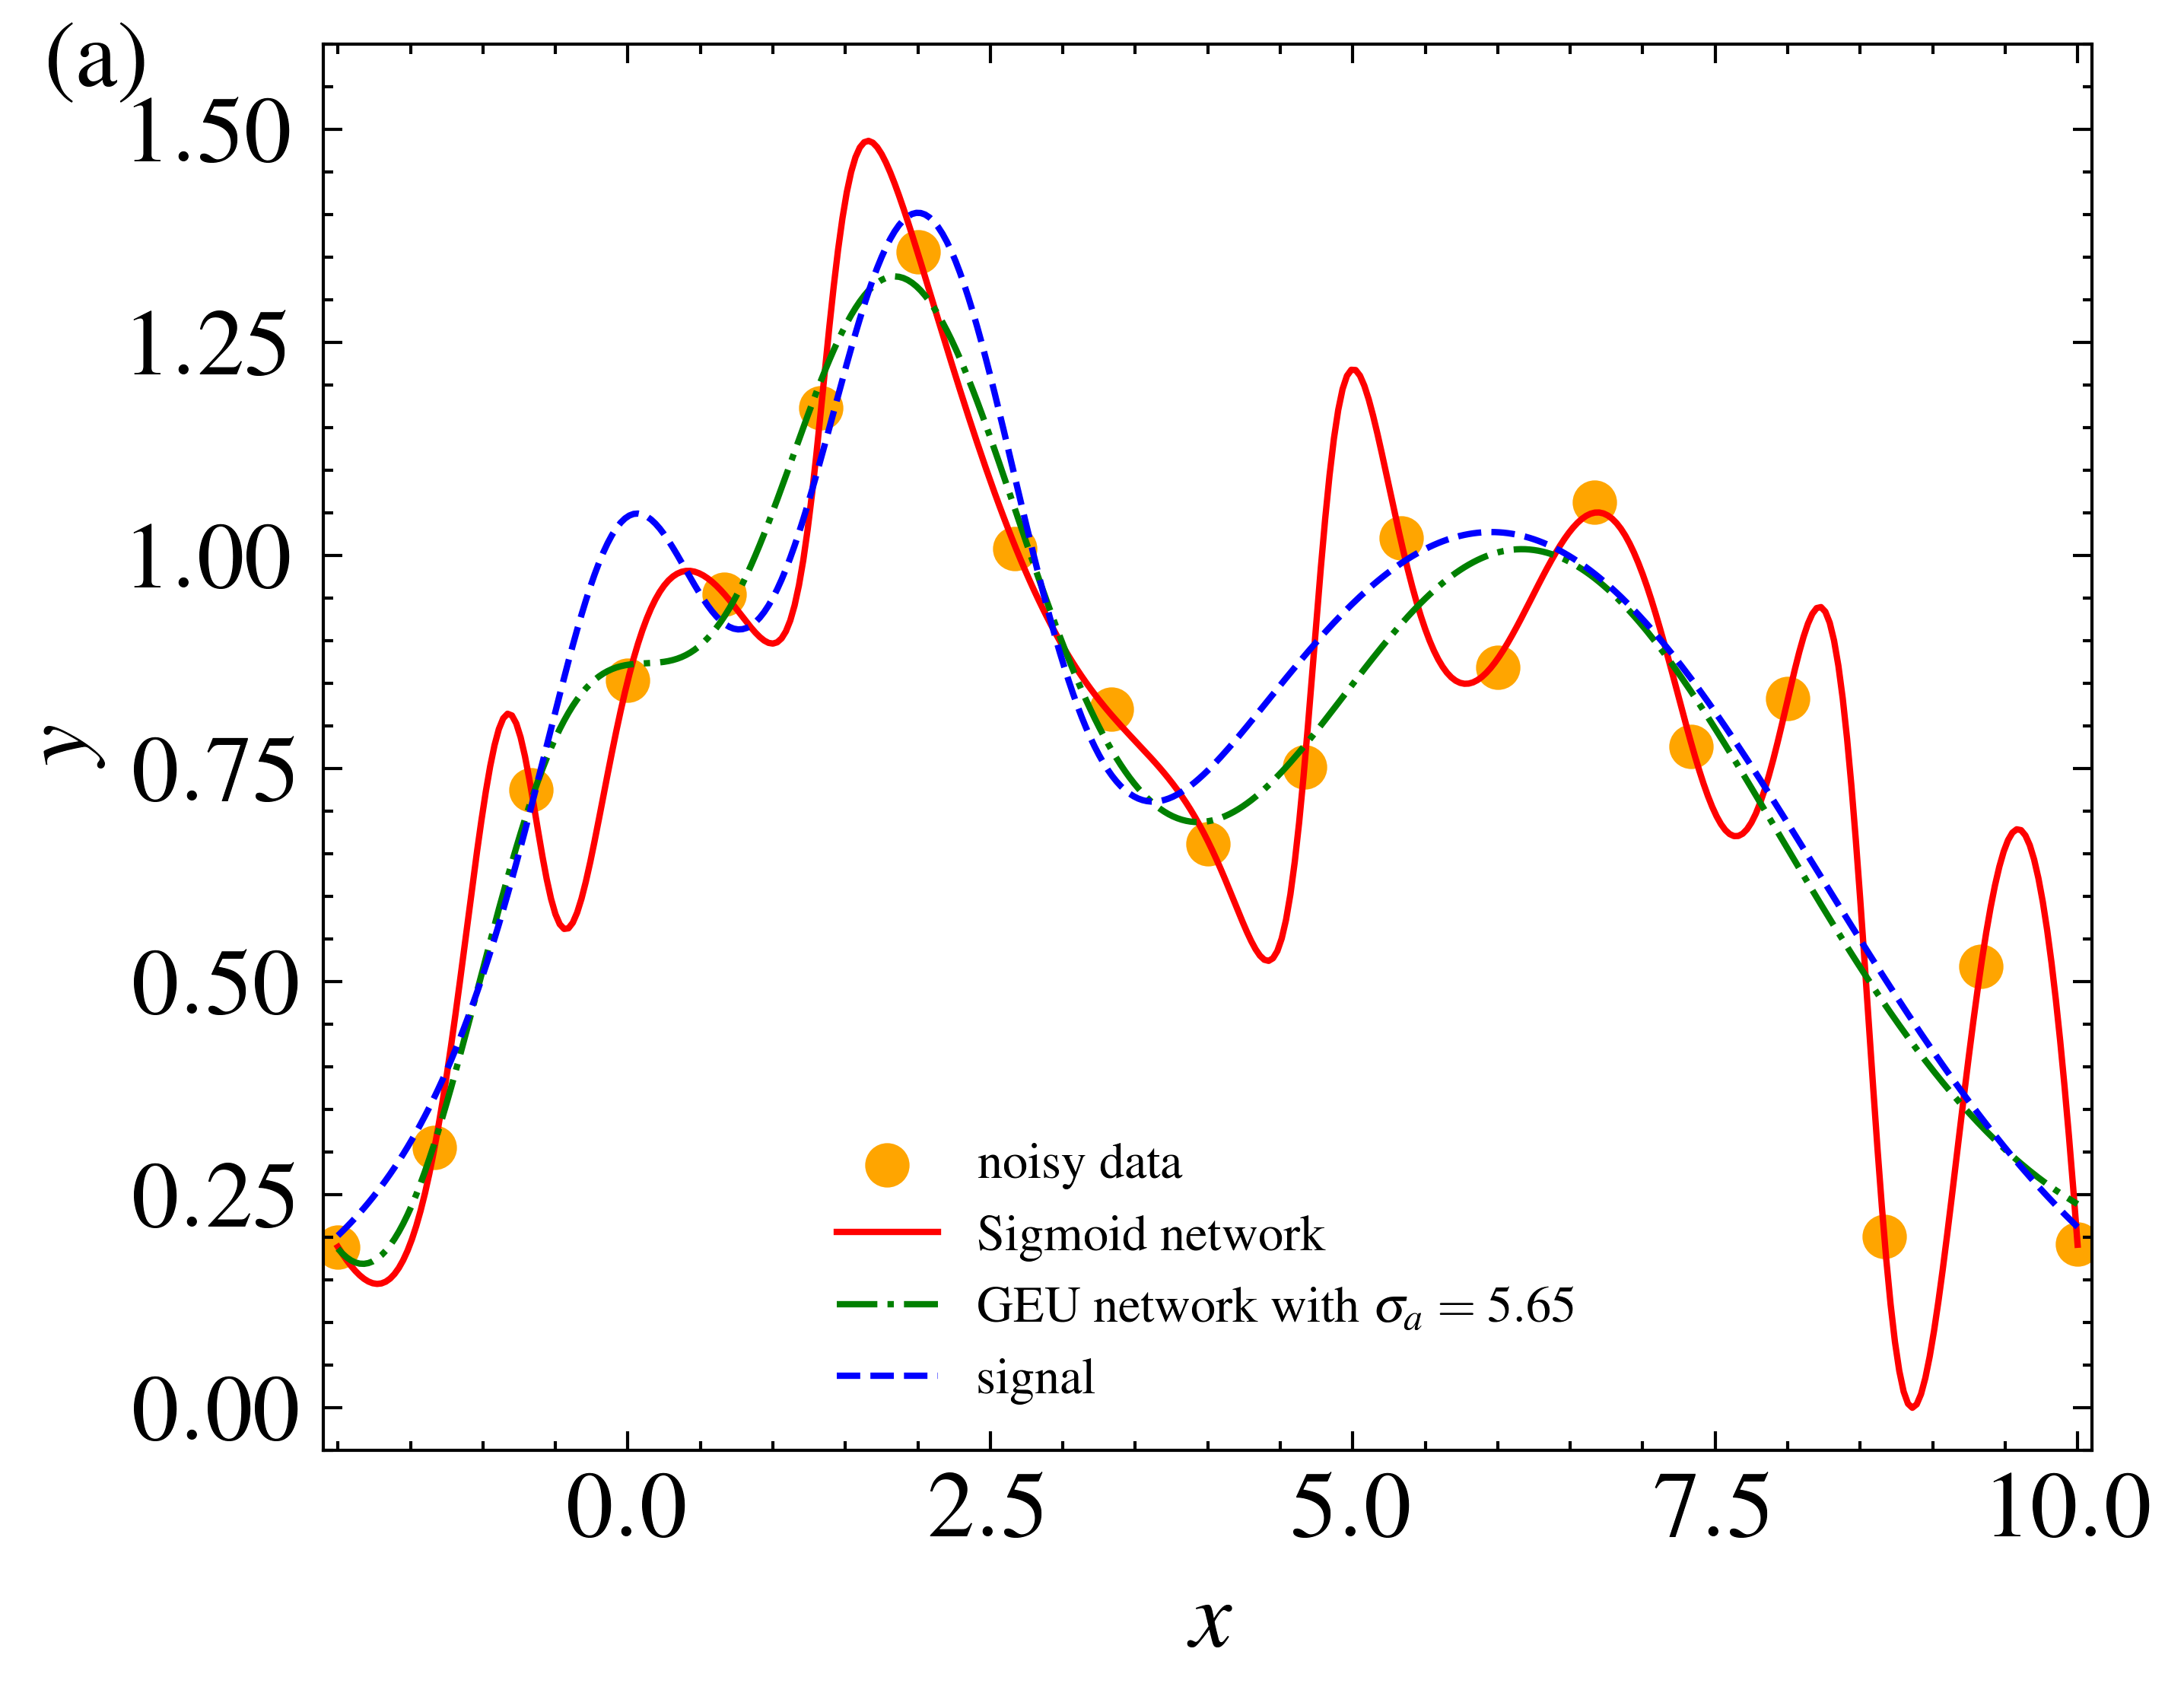

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('$x$', fontsize=15)
ax.set_ylabel('$y$', fontsize=15)
ax.set_xlim(-2.1, 10.1)
ax.set_ylim(-0.05, 1.6)

# Scatter plot for training set
ax.scatter(x.data.numpy(), y.data.numpy(), color="orange", label='noisy data')

# Generate input and output for the plot
input = torch.unsqueeze(torch.linspace(-2, 10, 401), dim=1)
outputg = net(input)

# Plot network fitting output
ax.plot(input.data.numpy(), output.data.numpy(), 'r-', lw=1, label='Sigmoid network')
ax.plot(input.data.numpy(), outputg.data.numpy(), 'g-.', lw=1, label=r'GEU network with $\sigma_{a}=5.65$')
# True signal
signal = np.exp(-(input - 2)**2) + np.exp(-(input - 6)**2 / 10) + 1 / (input**2 + 1)
ax.plot(input.data.numpy(), signal.data.numpy(), 'b--', lw=1, label='signal')

# Save output to CSV file
output_data = np.hstack((input.data.numpy(), output.data.numpy()))
output_datag = np.hstack((input.data.numpy(), outputg.data.numpy()))
np.savetxt('D:/MST2024/outputsigmoid.csv', output_data, delimiter=',', header='x,output', comments='')
np.savetxt('D:/MST2024/outputGEU.csv', output_datag, delimiter=',', header='x,output', comments='')
ax.text(-4, 1.55, '(a)',fontdict={'size': 15, 'color':  'black'})
# Save figure as EPS file
plt.legend()
#plt.savefig('D:/MST2024/Fig2a.eps', format='eps')
plt.show()

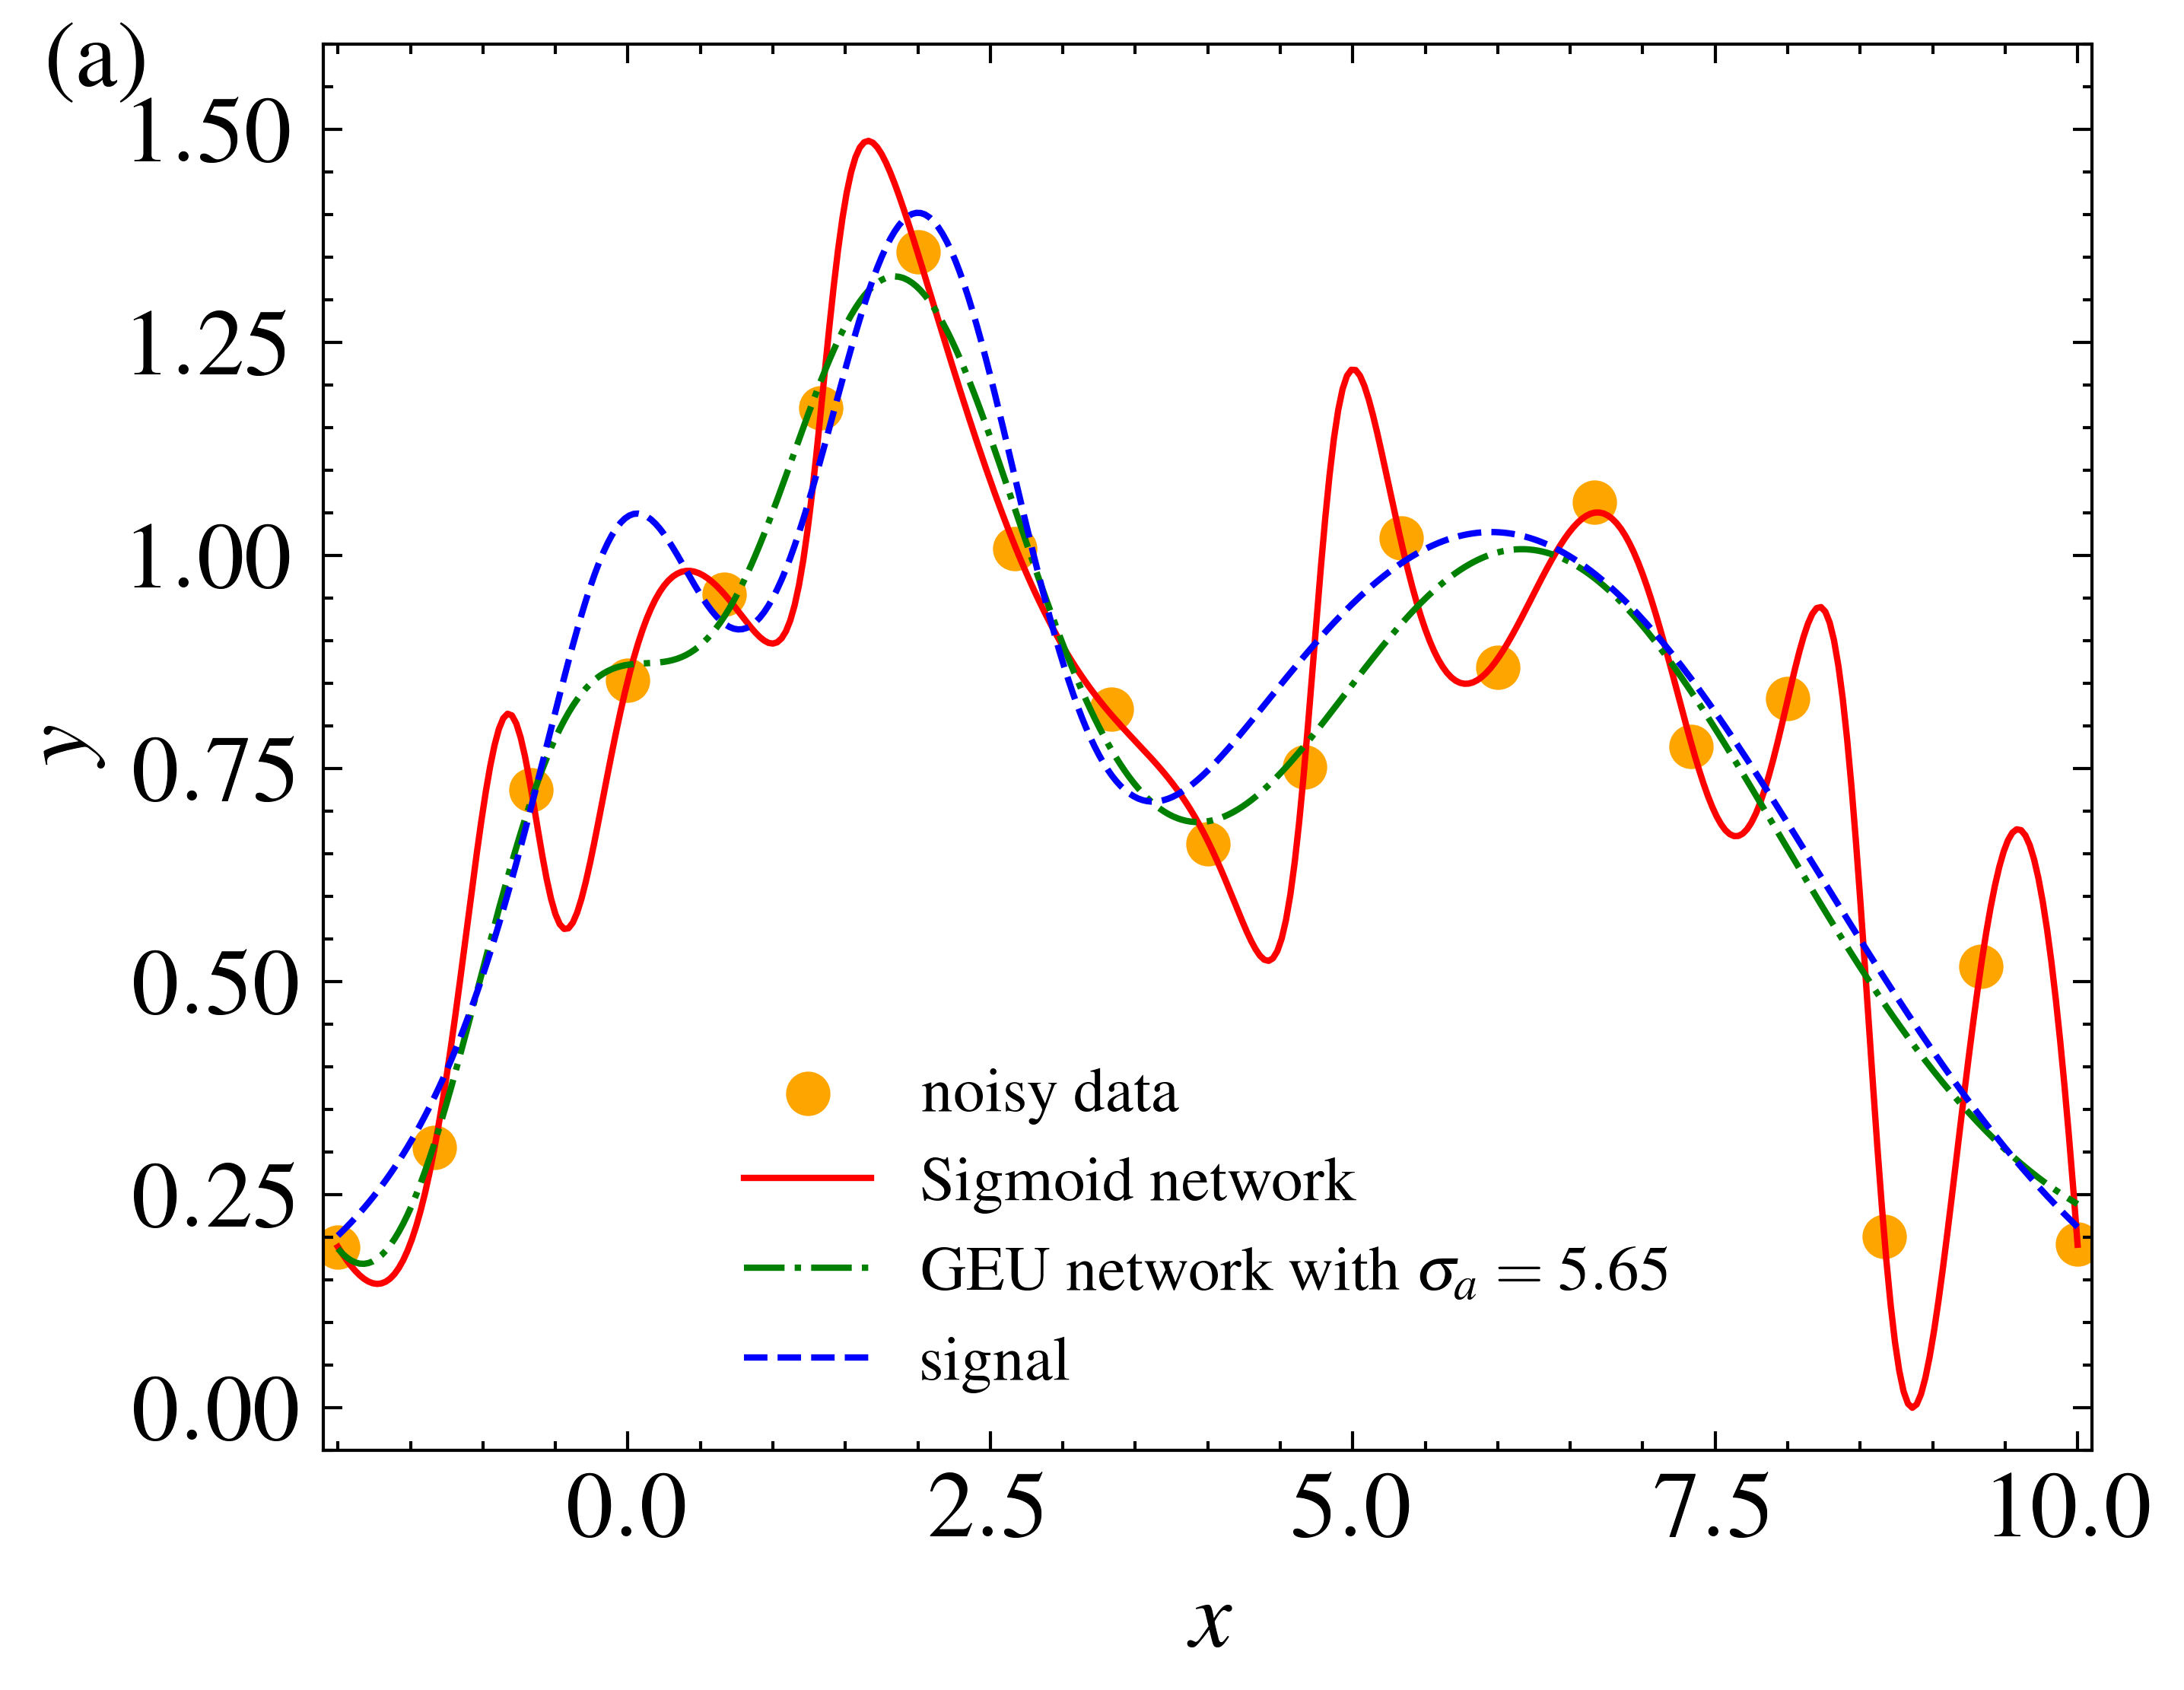

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import numpy as np

# ... (your existing code for net, x, y, etc.)

fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('$x$', fontsize=15)
ax.set_ylabel('$y$', fontsize=15)
ax.set_xlim(-2.1, 10.1)
ax.set_ylim(-0.05, 1.6)

# Scatter plot for training set
ax.scatter(x.data.numpy(), y.data.numpy(), color="orange", label='noisy data')

# Generate input and output for the plot
input = torch.unsqueeze(torch.linspace(-2, 10, 401), dim=1)
outputg = net(input)

# Plot network fitting output
ax.plot(input.data.numpy(), output.data.numpy(), 'r-', lw=1, label='Sigmoid network')

output_datag = np.loadtxt('D:/MST2024/outputGEU.csv', delimiter=',', skiprows=1)
x = output_datag[:, 0]
outputg = output_datag[:, 1]
ax.plot(x, outputg, 'g-.', lw=1, label=r'GEU network with $\sigma_{a}=5.65$')
# True signal
signal = np.exp(-(input - 2)**2) + np.exp(-(input - 6)**2 / 10) + 1 / (input**2 + 1)
ax.plot(input.data.numpy(), signal.data.numpy(), 'b--', lw=1, label='signal')

ax.text(-4, 1.55, '(a)',fontdict={'size': 15, 'color':  'black'})

# Set legend font size (recommended way)
plt.legend(fontsize=10)  # directly set the fontsize here

# Or, the slightly more verbose way:
# legend = ax.legend()
# for text in legend.get_texts():
#     plt.setp(text, fontsize=12)

# Save figure as EPS file
plt.savefig('D:/MST2024/Fig2a.eps', format='eps')
plt.show()

In [ ]:
####
#第2部分我们用x数据中加噪声进行贝叶斯优化optuna
import random
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import optuna
from tqdm import tqdm
#seeds = random.sample(range(1, 10000), 10)
#print(seeds)[7221, 1915, 123, 1486, 9540, 573, 1376, 1613, 5811, 3880]
#固定测试种子实验

In [2]:
# Set initial seed
SEED = 1234
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

# Define data
x = torch.unsqueeze(torch.linspace(-2, 10, 19), dim=1)
ytrain = np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2 / 10) + 1 / (x**2 + 1) + 0.12 * torch.randn(x.size())

# Define network
class Net(nn.Module):
    def __init__(self, n_feature, n_hidden1, n_output):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(n_feature, n_hidden1)
        self.predict = nn.Linear(n_hidden1, n_output)

    def forward(self, x):
        x = torch.sigmoid(self.hidden1(x))
        return self.predict(x)

    def reset_parameters(self):
        self.hidden1.reset_parameters()
        self.predict.reset_parameters()

# Optimization objective
def objective(trial):
    net = Net(n_feature=1, n_hidden1=14, n_output=1)
    optimizer = optim.Adam(net.parameters(), lr=0.01, betas=(0.99, 0.99))
    loss_func = nn.MSELoss()

    sigma = trial.suggest_float("sigma", 0.0, 0.12)
    NJnum = 10
    epoch = 15000
    train_losses = []

    for num in range(NJnum):
        seed = random.sample(range(1, 1000), 1)[0]
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        x_noisy = x + sigma * torch.randn(x.size())
        ytrain_noisy = ytrain.clone()

        net.reset_parameters()

        for _ in range(epoch):
            net.train()
            prediction = net(x_noisy)
            loss = loss_func(prediction, ytrain_noisy)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)

    # Test phase
    #seeds = random.sample(range(1, 1000), 10)
    seeds = [7221, 1915, 123, 1486, 9540, 573, 1376, 1613, 5811, 3880]
    test_losses = []

    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        x_test = torch.unsqueeze(torch.linspace(-2, 10, 30), dim=1)
        y_test = np.exp(-(x_test - 2)**2) + np.exp(-(x_test - 6)**2 / 10) + 1 / (x_test**2 + 1) + 0.12 * torch.randn(x_test.size())

        net.eval()
        with torch.no_grad():
            prediction_test = net(x_test)
            test_loss = loss_func(prediction_test, y_test)
            test_losses.append(test_loss.item())

    mean_test_loss = np.mean(test_losses)
    objective_value = (mean_test_loss / train_loss - 1) ** 2
    #objective_value = np.mean(test_losses)
    return objective_value

# Run optimization
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),  # Use TPE sampler with seed
    pruner=optuna.pruners.MedianPruner()  # Use median pruner for early stopping
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

best_sigma = study.best_params["sigma"]

[I 2024-07-02 18:47:54,546] A new study created in memory with name: no-name-566343b1-79f3-4079-b9b7-dd248ac0505d


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2024-07-02 18:49:47,683] Trial 0 finished with value: 75.70985552335777 and parameters: {'sigma': 0.022982334045467075}. Best is trial 0 with value: 75.70985552335777.
[I 2024-07-02 18:51:40,506] Trial 1 finished with value: 75.52747928555992 and parameters: {'sigma': 0.07465305252477981}. Best is trial 1 with value: 75.52747928555992.
[I 2024-07-02 18:53:34,203] Trial 2 finished with value: 59.958294722187595 and parameters: {'sigma': 0.05252732868085373}. Best is trial 2 with value: 59.958294722187595.
[I 2024-07-02 18:55:28,069] Trial 3 finished with value: 169.78878692570848 and parameters: {'sigma': 0.0942430300456523}. Best is trial 2 with value: 59.958294722187595.
[I 2024-07-02 18:57:22,525] Trial 4 finished with value: 24.486454170439366 and parameters: {'sigma': 0.09359709697425642}. Best is trial 4 with value: 24.486454170439366.
[I 2024-07-02 18:59:16,831] Trial 5 finished with value: 38.28858822278395 and parameters: {'sigma': 0.032711112633916996}. Best is trial 4 with

In [3]:
best_sigma = study.best_params["sigma"]
print(best_sigma)

0.09359709697425642


Best hyperparameter (sigma): 0.09359709697425642
Mean Train Loss: 0.0026579654879867578


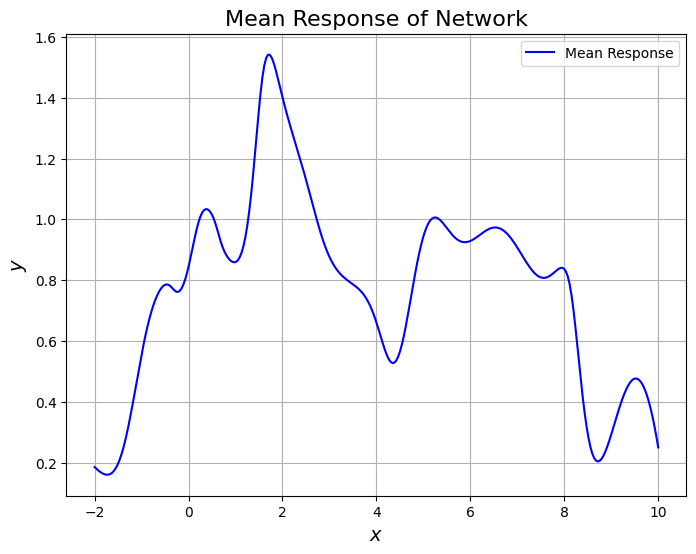

Best hyperparameter (sigma): 0.09359709697425642
Mean Test Loss: 0.0614042691886425
Mean Train Loss: 0.0026579654879867578


In [4]:
import random
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

# Define your neural network architecture
class Net(nn.Module):
    def __init__(self, n_feature, n_hidden1, n_output):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(n_feature, n_hidden1)
        self.predict = nn.Linear(n_hidden1, n_output)

    def forward(self, x):
        x = torch.sigmoid(self.hidden1(x))
        return self.predict(x)

    def reset_parameters(self):
        self.hidden1.reset_parameters()
        self.predict.reset_parameters()


# Initialize hyperparameters and network
net = Net(n_feature=1, n_hidden1=14, n_output=1)
optimizer = optim.Adam(net.parameters(), lr=0.01, betas=(0.99, 0.99))
loss_func = nn.MSELoss()

# Define training settings
NJnum = 10
epoch = 15000

# Placeholder for best_sigma, replace with actual value from optimization
#best_sigma =   # Replace with your best found sigma value
best_sigma = study.best_params["sigma"]
SEED = 1234
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

# Placeholder for x and ytrain, replace with your data
x = torch.unsqueeze(torch.linspace(-2, 10, 19), dim=1)
ytrain = np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2+1) + 0.12 * torch.randn(x.size())

# Define x_respond for response plotting
x_respond = torch.unsqueeze(torch.linspace(-2, 10, 300), dim=1)

# Initialize lists to store losses and responses
train_losses = []
responses = []

# Training loop with noisy data
for num in range(NJnum):
    seed = random.sample(range(1, 10000), 1)[0]
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    x_noisy = x + best_sigma * torch.randn(x.size())
    ytrain_noisy = ytrain.clone()

    net.reset_parameters()

    # Training loop
    for _ in range(epoch):
        net.train()
        prediction = net(x_noisy)
        loss = loss_func(prediction, ytrain_noisy)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Append the train loss
    train_losses.append(loss.item())

    # Calculate mean response for x_respond after training
    net.eval()
    with torch.no_grad():
        response = net(x_respond)
        responses.append(response.numpy())

# Calculate mean train loss
mean_train_loss = np.mean(train_losses)

# Calculate mean response across NJnum runs
mean_response = np.mean(responses, axis=0)

# Print results
print("Best hyperparameter (sigma):", best_sigma)
print("Mean Train Loss:", mean_train_loss)

# Plotting responses
plt.figure(figsize=(8, 6))
plt.plot(x_respond.numpy(), mean_response, label='Mean Response', color='blue')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.title('Mean Response of Network', fontsize=16)
plt.grid(True)
plt.legend()
plt.show()

# Test phase
seeds = random.sample(range(1, 10000), 10)
test_losses = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    x_test = torch.unsqueeze(torch.linspace(-2, 10, 30), dim=1)
    y_test = np.exp(-(x_test - 2)**2) + np.exp(-(x_test - 6)**2 / 10) + 1 / (x_test**2 + 1) + 0.12 * torch.randn(x_test.size())

    net.eval()
    with torch.no_grad():
        prediction_test = net(x_test)
        test_loss = loss_func(prediction_test, y_test)
        test_losses.append(test_loss.item())

mean_test_loss = np.mean(test_losses)

print("Best hyperparameter (sigma):", best_sigma)
print("Mean Test Loss:", mean_test_loss)
print("Mean Train Loss:", mean_train_loss)

In [5]:
# Configure plot settings
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = True
plt.style.use(['science', 'ieee'])
plt.rcParams['text.usetex'] = True
# Generate figure and axis
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('$x$', fontsize=15)
ax.set_ylabel('$y$', fontsize=15)
ax.set_xlim(-2.1, 10.1)
ax.set_ylim(-0.05, 1.6)

# Scatter plot for training set
ax.scatter(x.data.numpy(), ytrain.data.numpy(), color="orange", label='noisy data')

input = torch.unsqueeze(torch.linspace(-2, 10, 401), dim=1)
signal = np.exp(-(input - 2)**2) + np.exp(-(input - 6)**2 / 10) + 1 / (input**2 + 1)
ax.plot(input.data.numpy(), signal.data.numpy(), 'b--', lw=1, label='signal')


# Plot network fitting output
#ax.plot(inputx.data.numpy(), output.data.numpy(), 'r-', lw=1, label='$\sigma_{\mathrm{input}}=0.1474$')
plt.plot(x_respond.numpy(), mean_response, label='Mean Response', color='blue')
# True signal
#signal = np.exp(-(inputx - 2)**2) + np.exp(-(inputx - 6)**2 / 10) + 1 / (inputx**2 + 1)
#ax.plot(inputx.data.numpy(), signal.data.numpy(), 'b--', lw=1, label='signal')

# Save output to CSV file
#output_data = np.hstack((inputx.data.numpy(), output.data.numpy()))
#np.savetxt('D:/PLA2024/outputsigmoidxnoise.csv', output_data, delimiter=',', header='x,output', comments='')
ax.text(-4, 1.55, '(c)',fontdict={'size': 15, 'color':  'black'})
# Save figure as EPS file
# Show plot
plt.legend()
plt.savefig('D:/PLA2024/Fig2c.eps', format='eps')
plt.show()

NameError: name 'mpl' is not defined

In [10]:
import pandas as pd

# Convert data to DataFrame
data = pd.DataFrame({
    'x_respond': x_respond.numpy().flatten(),
    'mean_response': mean_response.flatten()
})

# Save to CSV
data.to_csv('D:/PLA2024/Sigmoiddata+noise20240630.csv', index=False)

In [11]:
#第2部分我们用y标签中加噪声进行贝叶斯优化optuna
import random
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import optuna
from tqdm import tqdm

# Set initial seed
SEED = 1234
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True

# Define data
x = torch.unsqueeze(torch.linspace(-2, 10, 19), dim=1)
ytrain = np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2 / 10) + 1 / (x**2 + 1) + 0.12 * torch.randn(x.size())

# Define network
class Net(nn.Module):
    def __init__(self, n_feature, n_hidden1, n_output):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(n_feature, n_hidden1)
        self.predict = nn.Linear(n_hidden1, n_output)

    def forward(self, x):
        x = torch.sigmoid(self.hidden1(x))
        return self.predict(x)

    def reset_parameters(self):
        self.hidden1.reset_parameters()
        self.predict.reset_parameters()

# Optimization objective
def objective(trial):
    net = Net(n_feature=1, n_hidden1=14, n_output=1)
    optimizer = optim.Adam(net.parameters(), lr=0.01, betas=(0.99, 0.99))
    loss_func = nn.MSELoss()

    sigma = trial.suggest_float("sigma", 0.0, 0.12)
    NJnum = 10
    epoch = 15000
    train_losses = []

    for num in range(NJnum):
        seed = random.sample(range(1, 1000), 1)[0]
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        x_noisy = x.clone()
        ytrain_noisy = ytrain+sigma * torch.randn(x.size())

        net.reset_parameters()

        for _ in range(epoch):
            net.train()
            prediction = net(x_noisy)
            loss = loss_func(prediction, ytrain_noisy)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_losses.append(loss.item())

    train_loss = np.mean(train_losses)

    # Test phase
    seeds = random.sample(range(1, 1000), 10)
    test_losses = []

    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        x_test = torch.unsqueeze(torch.linspace(-2, 10, 30), dim=1)
        y_test = np.exp(-(x_test - 2)**2) + np.exp(-(x_test - 6)**2 / 10) + 1 / (x_test**2 + 1) + 0.12 * torch.randn(x_test.size())

        net.eval()
        with torch.no_grad():
            prediction_test = net(x_test)
            test_loss = loss_func(prediction_test, y_test)
            test_losses.append(test_loss.item())

    mean_test_loss = np.mean(test_losses)
    objective_value = -(mean_test_loss / train_loss - 1) ** 2

    return objective_value

# Run optimization
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),  # Use TPE sampler with seed
    pruner=optuna.pruners.MedianPruner()  # Use median pruner for early stopping
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

best_sigma = study.best_params["sigma"]

[I 2024-06-30 11:44:21,368] A new study created in memory with name: no-name-5ef7d665-53af-4a06-a39b-7bcdf54e13ab


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2024-06-30 11:46:13,044] Trial 0 finished with value: -43.51686728206083 and parameters: {'sigma': 0.022982334045467075}. Best is trial 0 with value: -43.51686728206083.
[I 2024-06-30 11:48:06,765] Trial 1 finished with value: -44.89132462135591 and parameters: {'sigma': 0.07465305252477981}. Best is trial 0 with value: -43.51686728206083.
[I 2024-06-30 11:50:04,465] Trial 2 finished with value: -50.67173098636229 and parameters: {'sigma': 0.05252732868085373}. Best is trial 0 with value: -43.51686728206083.
[I 2024-06-30 11:52:03,943] Trial 3 finished with value: -67.01096998068876 and parameters: {'sigma': 0.0942430300456523}. Best is trial 0 with value: -43.51686728206083.
[I 2024-06-30 11:54:08,974] Trial 4 finished with value: -89.0999657616634 and parameters: {'sigma': 0.09359709697425642}. Best is trial 0 with value: -43.51686728206083.
[I 2024-06-30 11:56:11,212] Trial 5 finished with value: -337.6768071621164 and parameters: {'sigma': 0.032711112633916996}. Best is trial 0 

In [12]:
best_sigma = study.best_params["sigma"]
print(best_sigma)

0.00025705600718592403


Best hyperparameter (sigma): 0.00025705600718592403
Mean Test Loss: 0.03270373474806547
Mean Train Loss: 0.0007876265794038772


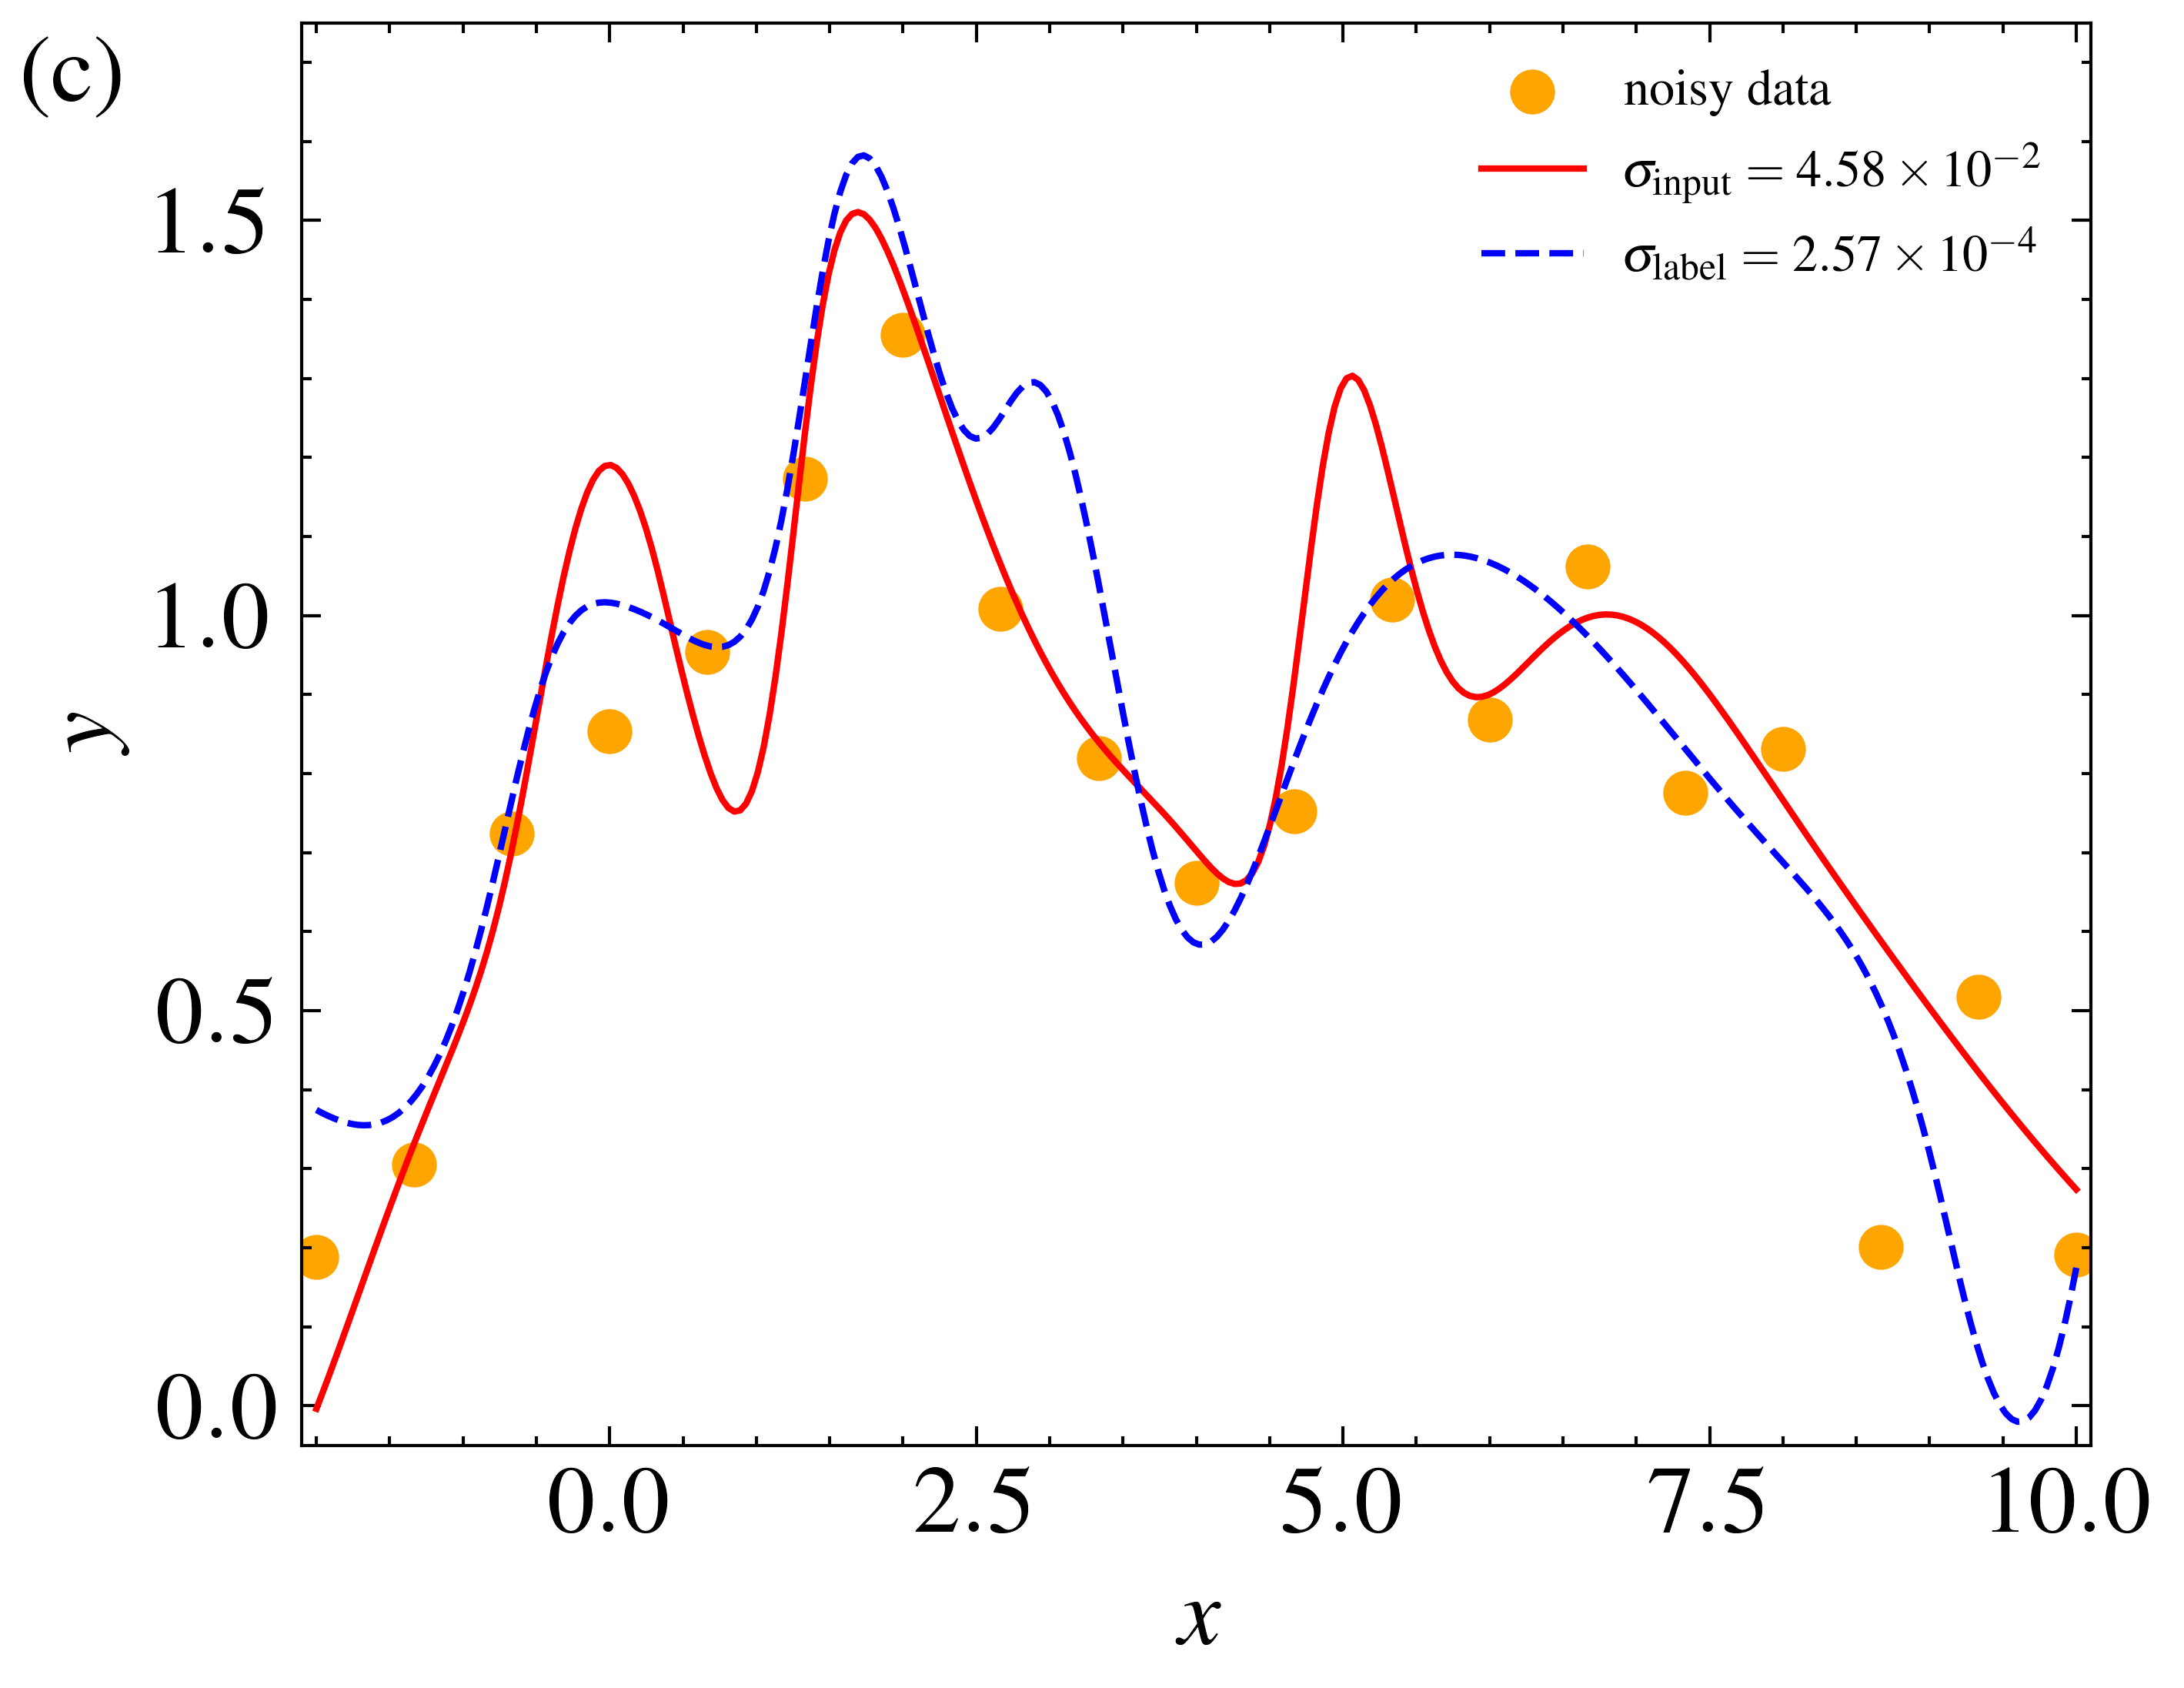

In [16]:
import random
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

# Define your neural network architecture
class Net(nn.Module):
    def __init__(self, n_feature, n_hidden1, n_output):
        super(Net, self).__init__()
        self.hidden1 = nn.Linear(n_feature, n_hidden1)
        self.predict = nn.Linear(n_hidden1, n_output)

    def forward(self, x):
        x = torch.sigmoid(self.hidden1(x))
        return self.predict(x)

    def reset_parameters(self):
        self.hidden1.reset_parameters()
        self.predict.reset_parameters()


# Initialize hyperparameters and network
net = Net(n_feature=1, n_hidden1=14, n_output=1)
optimizer = optim.Adam(net.parameters(), lr=0.01, betas=(0.99, 0.99))
loss_func = nn.MSELoss()

# Define training settings
NJnum = 10
epoch = 15000

# Placeholder for best_sigma, replace with actual value from optimization
#best_sigma = 0.004575416693207473  # Replace with your best found sigma value
best_sigma = study.best_params["sigma"]

# Placeholder for x and ytrain, replace with your data
x = torch.unsqueeze(torch.linspace(-2, 10, 19), dim=1)
ytrain = np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2+1) + 0.12 * torch.randn(x.size())

# Define x_respond for response plotting
x_respond = torch.unsqueeze(torch.linspace(-2, 10, 300), dim=1)

# Initialize lists to store losses and responses
train_losses = []
responsesy = []

# Training loop with noisy data
for num in range(NJnum):
    seed = random.sample(range(1, 10000), 1)[0]
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    x_noisy = x.clone() 
    ytrain_noisy = ytrain + best_sigma * torch.randn(x.size())

    net.reset_parameters()

    # Training loop
    for _ in range(epoch):
        net.train()
        prediction = net(x_noisy)
        loss = loss_func(prediction, ytrain_noisy)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Append the train loss
    train_losses.append(loss.item())

    # Calculate mean response for x_respond after training
    net.eval()
    with torch.no_grad():
        responsey = net(x_respond)
        responsesy.append(responsey.numpy())

# Calculate mean train loss
mean_train_loss = np.mean(train_losses)

# Calculate mean response across NJnum runs
mean_responsey = np.mean(responsesy, axis=0)

# Test phase
seeds = random.sample(range(1, 10000), 10)
test_losses = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    x_test = torch.unsqueeze(torch.linspace(-2, 10, 30), dim=1)
    y_test = np.exp(-(x_test - 2)**2) + np.exp(-(x_test - 6)**2 / 10) + 1 / (x_test**2 + 1) + 0.12 * torch.randn(x_test.size())

    net.eval()
    with torch.no_grad():
        prediction_test = net(x_test)
        test_loss = loss_func(prediction_test, y_test)
        test_losses.append(test_loss.item())

mean_test_loss = np.mean(test_losses)

print("Best hyperparameter (sigma):", best_sigma)
print("Mean Test Loss:", mean_test_loss)
print("Mean Train Loss:", mean_train_loss)


# Configure plot settings
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = True
plt.style.use(['science', 'ieee'])
plt.rcParams['text.usetex'] = True
# Generate figure and axis
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('$x$', fontsize=15)
ax.set_ylabel('$y$', fontsize=15)
ax.set_xlim(-2.1, 10.1)
ax.set_ylim(-0.05, 1.75)

# Scatter plot for training set
ax.scatter(x.data.numpy(), y.data.numpy(), color="orange", label='noisy data')

plt.plot(x_respond.numpy(), mean_response, 'r-', label=r'$\sigma_{\mathrm{input}}=4.58\times 10^{-2}$')
plt.plot(x_respond.numpy(), mean_responsey, 'b--', label=r'$\sigma_{\mathrm{label}}=2.57\times 10^{-4}$')
#output_data = np.hstack((inputx.data.numpy(), output.data.numpy()))
#np.savetxt('D:/PLA2024/outputsigmoidxnoise.csv', output_data, delimiter=',', header='x,output', comments='')
ax.text(-4, 1.65, '(c)',fontdict={'size': 15, 'color':  'black'})
# Save figure as EPS file
# Show plot
plt.legend()
plt.savefig('D:/PLA2024/Fig2c.eps', format='eps')
plt.show()

In [21]:
import pandas as pd

# Convert data to DataFrame
data = pd.DataFrame({
    'x_respond': x_respond.numpy().flatten(),
    'mean_responsey': mean_responsey.flatten()
})

# Save to CSV
data.to_csv('D:/PLA2024/Sigmoidlabel+noise20240630.csv', index=False)

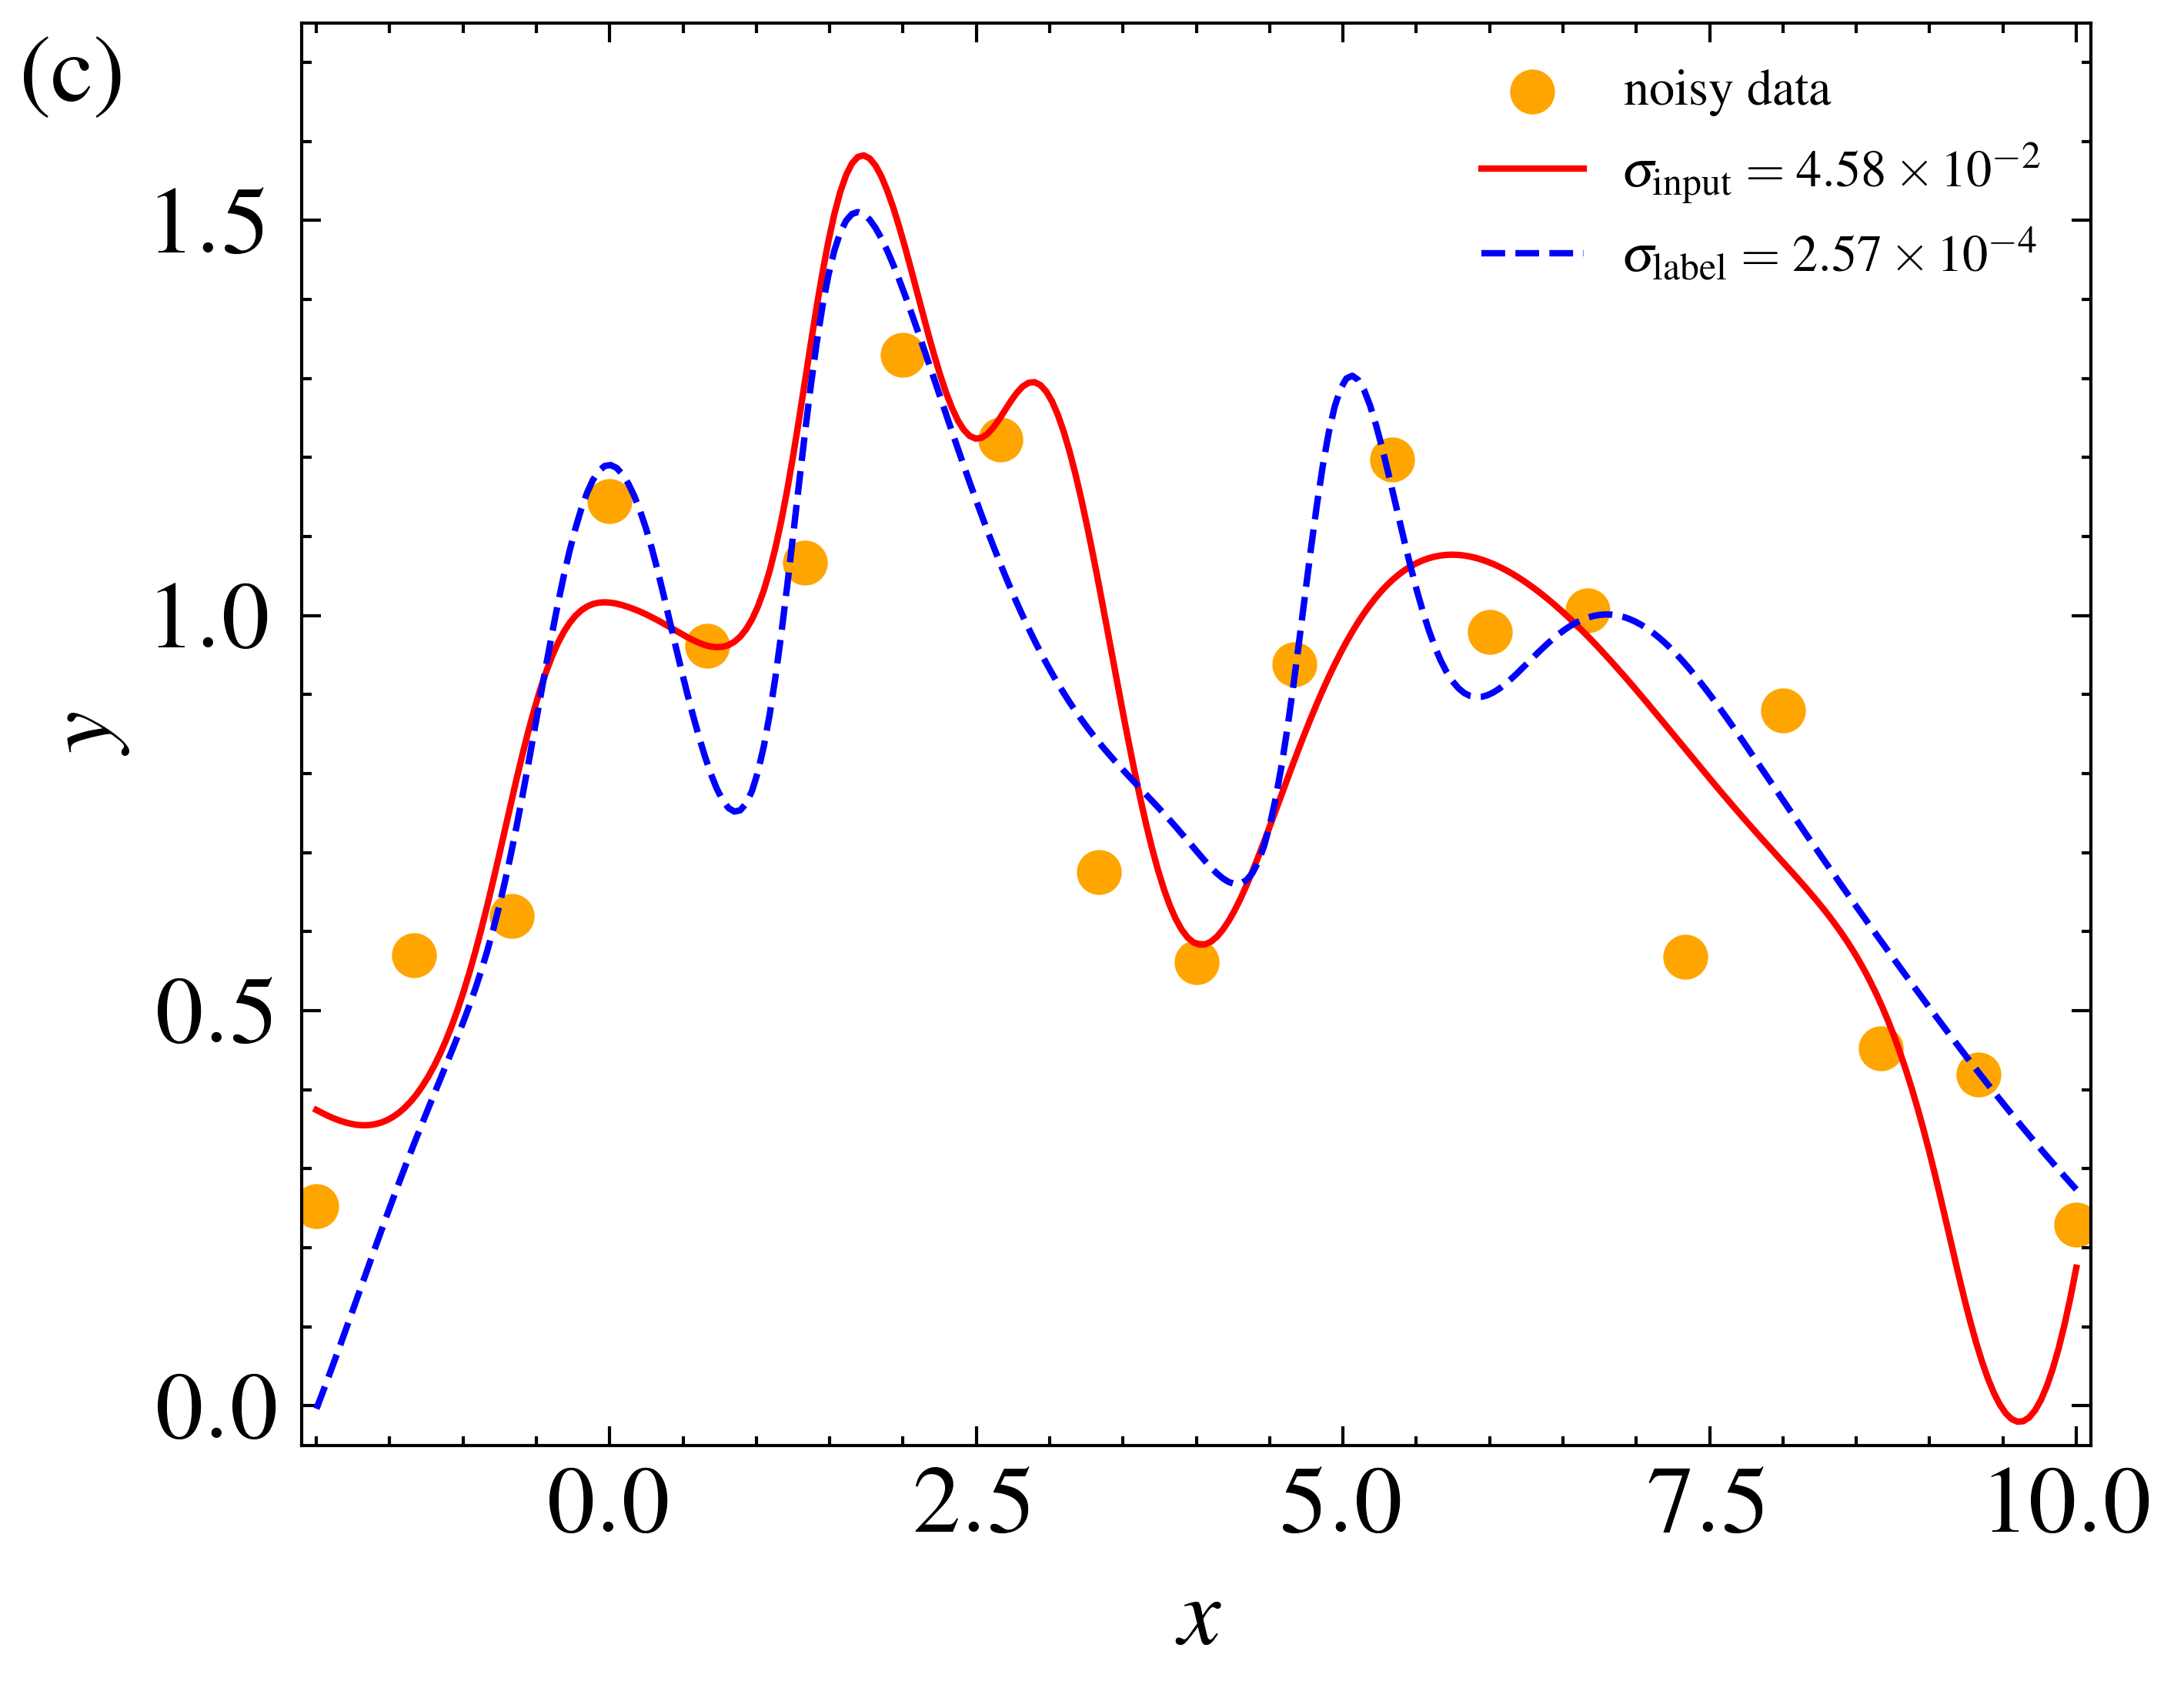

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取CSV文件
sigmoid_label = pd.read_csv('D:/PLA2024/Sigmoidlabel+noise20240630.csv')
sigmoid_data = pd.read_csv('D:/PLA2024/Sigmoiddata+noise20240630.csv')

# 提取数据
x_label = sigmoid_label.iloc[:, 0]
y_label = sigmoid_label.iloc[:, 1]
x_data = sigmoid_data.iloc[:, 0]
y_data = sigmoid_data.iloc[:, 1]

# 设置图形参数
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = True
plt.style.use(['science', 'ieee'])
plt.rcParams['text.usetex'] = True

# 创建图表
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
plt.tick_params(labelsize=15)
ax.set_xlabel('$x$', fontsize=15)
ax.set_ylabel('$y$', fontsize=15)
ax.set_xlim(-2.1, 10.1)
ax.set_ylim(-0.05, 1.75)

x = torch.unsqueeze(torch.linspace(-2, 10, 19), dim=1)
ytrain = np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2+1) + 0.12 * torch.randn(x.size())
# 绘制散点图
ax.scatter(x, ytrain, color="orange", label='noisy data')

# 绘制曲线图
plt.plot(x_label, y_label, 'r-', label=r'$\sigma_{\mathrm{input}}=4.58\times 10^{-2}$')
plt.plot(x_data, y_data, 'b--', label=r'$\sigma_{\mathrm{label}}=2.57\times 10^{-4}$')

# 添加文本
ax.text(-4, 1.65, '(c)', fontdict={'size': 15, 'color': 'black'})

# 显示图例和图像
plt.legend()
plt.show()